# 17. Network-Aware Portfolio Construction


## Data And Benchmarks


In [1]:
from pathlib import Path
import math
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from cycler import cycler
from IPython.display import display
from scipy.special import gammaln
from scipy.stats import t as student_t
from sklearn.covariance import LedoitWolf

from quantfinlab.dataio.panel import load_yfinance_panel, prices_to_returns_panel
from quantfinlab.portfolio import covariance, expected_returns
from quantfinlab.portfolio.universe import (
    build_liquid_universe_by_date,
    clean_close_volume_panels,
    make_rebalance_dates,
)
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.portfolio.hrp import hrp_weight_frame
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.portfolio.selection import build_strategy_summary, performance_metrics
from quantfinlab.reports.risk_report import risk_report

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2",
           "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update(
    {
        "figure.figsize": (6, 3),
        "figure.dpi": 200,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.20,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7,
    }
)


In [2]:
data_path = Path("../data")
if not (data_path / "nasdaq_all_close_volume.parquet").exists():
    data_path = Path("data")

primary_path = data_path / "nasdaq_all_close_volume.parquet"
start_date = "2016-01-01"
top_n = 100
lookback = 252
min_listing_days = 504
min_obs = 220
cost_bps = 10.0
w_min, w_max = 0.0, 0.10
annualization = 252
rf_annual = 0.04
rf_daily = (1.0 + rf_annual) ** (1.0 / annualization) - 1.0


In [3]:
panel = load_yfinance_panel(
    primary_path,
    fields=("close", "volume"),
    source="yfinance_export",
    start=start_date,
)
close, volume = clean_close_volume_panels(
    panel["close"],
    panel["volume"],
    start=start_date,
    min_price=1.0,
)
ret_d = prices_to_returns_panel(close).replace([np.inf, -np.inf], np.nan).dropna(how="all")

monthly_candidates = make_rebalance_dates(
    close.index,
    freq="M",
    min_history_days=min_listing_days,
)
sampled_candidates = pd.DatetimeIndex(monthly_candidates[::3])
universe_by_date = build_liquid_universe_by_date(
    close=close,
    volume=volume,
    rebalance_dates=sampled_candidates,
    top_n=top_n,
    liquidity_lookback=lookback,
    min_listing_days=min_listing_days,
    min_obs=min_obs,
    min_price=1.0,
)
rebalance_dates = pd.DatetimeIndex([dt for dt in sampled_candidates if dt in universe_by_date])


In [4]:
coverage = pd.DataFrame(
    {
        "value": [
            close.shape[0],
            close.shape[1],
            len(monthly_candidates),
            len(rebalance_dates),
            min(len(universe_by_date[dt]["tickers"]) for dt in rebalance_dates),
            max(len(universe_by_date[dt]["tickers"]) for dt in rebalance_dates),
        ]
    },
    index=[
        "trading days",
        "stocks after cleaning",
        "candidate monthly dates",
        "quarterly network dates",
        "minimum universe size",
        "maximum universe size",
    ],
)
display(coverage)
display(pd.DataFrame({"rebalance_date": rebalance_dates.date}))


,value
trading days,2532
stocks after cleaning,4139
candidate monthly dates,97
quarterly network dates,33
minimum universe size,100
maximum universe size,100


,rebalance_date
0,2018-01-31
1,2018-04-30
2,2018-07-31
3,2018-10-31
4,2019-01-31
5,2019-04-30
6,2019-07-31
7,2019-10-31
8,2020-01-31
9,2020-04-30


In [5]:
grid = run_walkforward_grid(
    returns=ret_d,
    close=close,
    volume=volume,
    rebalance_dates=rebalance_dates,
    universe_by_date=universe_by_date,
    mu_models={"Momentum": expected_returns.momentum_mu},
    cov_models={"LedoitWolf": covariance.ledoit_wolf_covariance},
    strategy_specs=[
        {"name": "Equal Weight", "optimizer": "EW"},
        {"name": "MinVar", "optimizer": "MinVar", "cov_model": "LedoitWolf"},
    ],
    cov_lookback=lookback,
    mu_lookback=lookback,
    min_cov_observations=min_obs,
    min_mu_observations=min_obs,
    max_weight=w_max,
    min_weight=w_min,
    long_only=True,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=cost_bps,
    fallback="equal",
    rf_daily=rf_daily,
    annualization=annualization,
)
w_equal = grid.weights["Equal Weight"].copy()
w_minvar = grid.weights["MinVar"].copy()
w_hrp = hrp_weight_frame(
    grid.cache,
    grid.metadata["rebalance_dates"],
    cov_model="LedoitWolf",
    linkage_method="average",
    w_min=w_min,
    w_max=w_max,
)


In [6]:
baseline_construction = pd.DataFrame(
    {
        "rebalance rows": [len(w_equal), len(w_minvar), len(w_hrp)],
        "latest invested": [w_equal.iloc[-1].sum(), w_minvar.iloc[-1].sum(), w_hrp.iloc[-1].sum()],
        "latest maximum weight": [w_equal.iloc[-1].max(), w_minvar.iloc[-1].max(), w_hrp.iloc[-1].max()],
    },
    index=["Equal Weight", "MinVar", "HRP"],
)
display(baseline_construction.round(4))


,rebalance rows,latest invested,latest maximum weight
Equal Weight,33,1.0,0.0100
MinVar,33,1.0,0.1000
HRP,32,1.0,0.0538


## Correlation Dependence


In [7]:
def clean_window(returns):
    out = returns.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return out.dropna(axis=0, how="any").dropna(axis=1, how="any").astype(float)


def shrink_corr(returns):
    window = clean_window(returns)
    cov = LedoitWolf().fit(window.to_numpy()).covariance_
    sigma = np.sqrt(np.maximum(np.diag(cov), 1e-16))
    corr = np.clip(cov / np.outer(sigma, sigma), -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    return pd.DataFrame(corr, index=window.columns, columns=window.columns)


def corr_distance(corr):
    values = np.sqrt(np.clip(2.0 * (1.0 - corr.to_numpy()), 0.0, 4.0))
    np.fill_diagonal(values, 0.0)
    return pd.DataFrame(values, index=corr.index, columns=corr.columns)


def matrix_heatmap(ax, matrix, title, cmap, vmin=None, vmax=None):
    image = ax.imshow(pd.DataFrame(matrix).to_numpy(dtype=float), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


In [8]:
first_dt = rebalance_dates[0]
first_names = list(universe_by_date[first_dt]["tickers"])
first_window = clean_window(ret_d.loc[:first_dt, first_names].tail(lookback))
corr_first = shrink_corr(first_window)
corr_dist_first = corr_distance(corr_first)


,Ledoit-Wolf correlation
window date,2018-01-31
observations,252
stocks,100
mean pairwise correlation,0.111351
maximum pairwise correlation,0.765615
mean correlation distance,1.330521


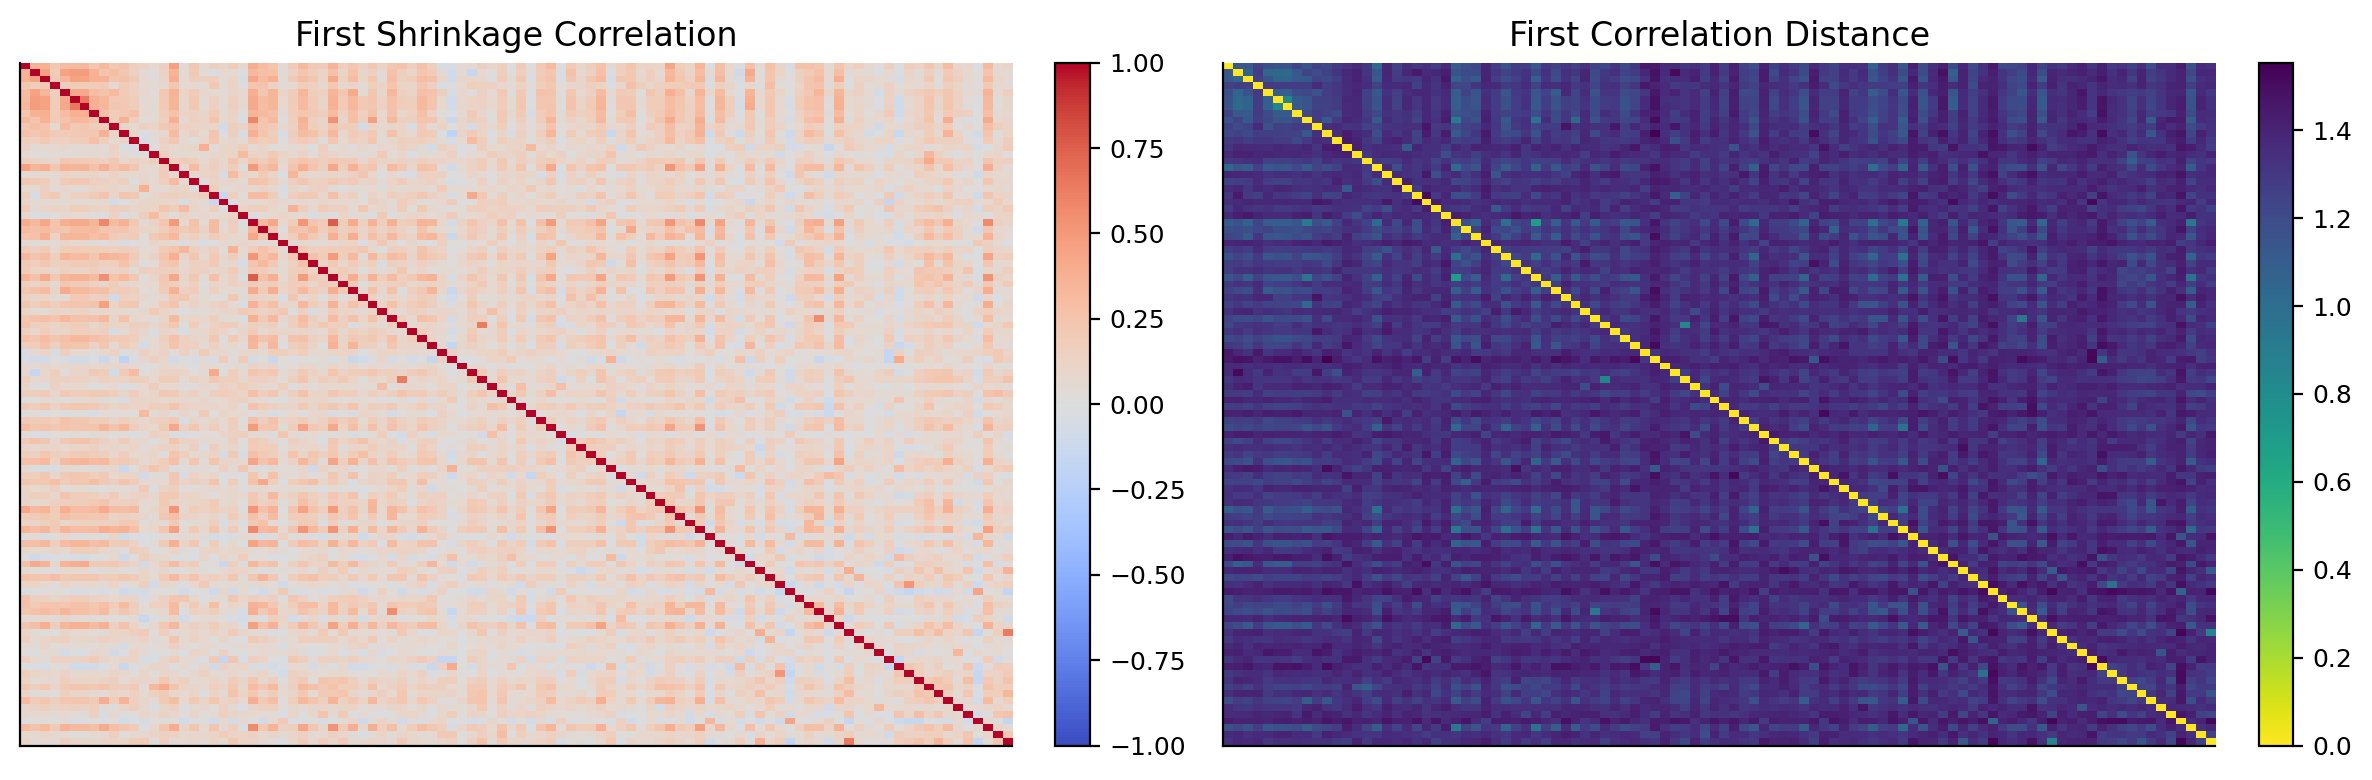

In [9]:
tri = np.triu_indices_from(corr_first, k=1)
corr_description = pd.Series(
    {
        "window date": first_dt.date(),
        "observations": len(first_window),
        "stocks": first_window.shape[1],
        "mean pairwise correlation": corr_first.to_numpy()[tri].mean(),
        "maximum pairwise correlation": corr_first.to_numpy()[tri].max(),
        "mean correlation distance": corr_dist_first.to_numpy()[tri].mean(),
    },
    name="Ledoit-Wolf correlation",
)
display(corr_description.to_frame().round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
matrix_heatmap(axes[0], corr_first, "First Shrinkage Correlation", "coolwarm", -1.0, 1.0)
matrix_heatmap(axes[1], corr_dist_first, "First Correlation Distance", "viridis_r")
fig.tight_layout()
plt.show()


## Student-t Copula Dependence


In [10]:
def pseudo_observations(returns):
    window = clean_window(returns)
    return (window.rank(axis=0, method="average") / (len(window) + 1.0)).clip(1e-6, 1.0 - 1e-6)


def kendall_to_t_copula_corr(pseudo):
    tau = pseudo.corr(method="kendall").fillna(0.0)
    rho = np.sin(0.5 * np.pi * tau.to_numpy())
    rho = np.clip(0.5 * (rho + rho.T), -0.995, 0.995)
    np.fill_diagonal(rho, 1.0)
    return pd.DataFrame(rho, index=pseudo.columns, columns=pseudo.columns)


def pair_sample(n_assets, max_pairs=40):
    pairs = list(combinations(range(n_assets), 2))
    if len(pairs) <= max_pairs:
        return pairs
    locations = np.linspace(0, len(pairs) - 1, max_pairs, dtype=int)
    return [pairs[i] for i in np.unique(locations)]


def student_t_copula_loglik(pseudo, rho, nu, pairs=None):
    x = student_t.ppf(pseudo.to_numpy(), df=float(nu))
    rho_values = rho.to_numpy()
    selected_pairs = pairs or pair_sample(pseudo.shape[1])
    uni_const = gammaln((nu + 1.0) / 2.0) - gammaln(nu / 2.0) - 0.5 * np.log(nu * np.pi)
    bi_const = gammaln((nu + 2.0) / 2.0) - gammaln(nu / 2.0) - np.log(nu * np.pi)
    values = []
    for i, j in selected_pairs:
        correlation = float(np.clip(rho_values[i, j], -0.995, 0.995))
        det = max(1.0 - correlation**2, 1e-12)
        left, right = x[:, i], x[:, j]
        quad = (left**2 - 2.0 * correlation * left * right + right**2) / det
        bivariate = bi_const - 0.5 * np.log(det) - 0.5 * (nu + 2.0) * np.log1p(quad / nu)
        marginal_left = uni_const - 0.5 * (nu + 1.0) * np.log1p(left**2 / nu)
        marginal_right = uni_const - 0.5 * (nu + 1.0) * np.log1p(right**2 / nu)
        values.append(float(np.nanmean(bivariate - marginal_left - marginal_right)))
    return float(np.nanmean(values))


def select_t_copula_nu(pseudo, nu_grid=(4, 7, 15), max_pairs=40):
    rho = kendall_to_t_copula_corr(pseudo)
    pairs = pair_sample(pseudo.shape[1], max_pairs=max_pairs)
    scores = {nu: student_t_copula_loglik(pseudo, rho, nu, pairs=pairs) for nu in nu_grid}
    return float(max(scores, key=scores.get)), pd.Series(scores, name="average log likelihood")


def student_t_tail_dependence(rho, nu):
    values = np.clip(rho.to_numpy(), -0.995, 0.995)
    arg = -np.sqrt(np.maximum((nu + 1.0) * (1.0 - values) / np.maximum(1.0 + values, 1e-10), 0.0))
    tail = np.clip(2.0 * student_t.cdf(arg, df=nu + 1.0), 0.0, 1.0)
    np.fill_diagonal(tail, 1.0)
    return pd.DataFrame(tail, index=rho.index, columns=rho.columns)


def dependence_to_distance(dependence):
    values = np.sqrt(np.clip(2.0 * (1.0 - dependence.to_numpy()), 0.0, 2.0))
    np.fill_diagonal(values, 0.0)
    return pd.DataFrame(values, index=dependence.index, columns=dependence.columns)


In [11]:
u_first = pseudo_observations(first_window)
rho_t_first = kendall_to_t_copula_corr(u_first)
nu_first, nu_scores_first = select_t_copula_nu(u_first)
tail_first = student_t_tail_dependence(rho_t_first, nu_first)
tail_dist_first = dependence_to_distance(tail_first)


,average log likelihood
4,0.0260
7,0.0310
15,0.0307


,Student-t copula
selected nu,7.0000
mean pairwise tail dependence,0.0536
maximum pairwise tail dependence,0.8382
mean tail distance,1.3755


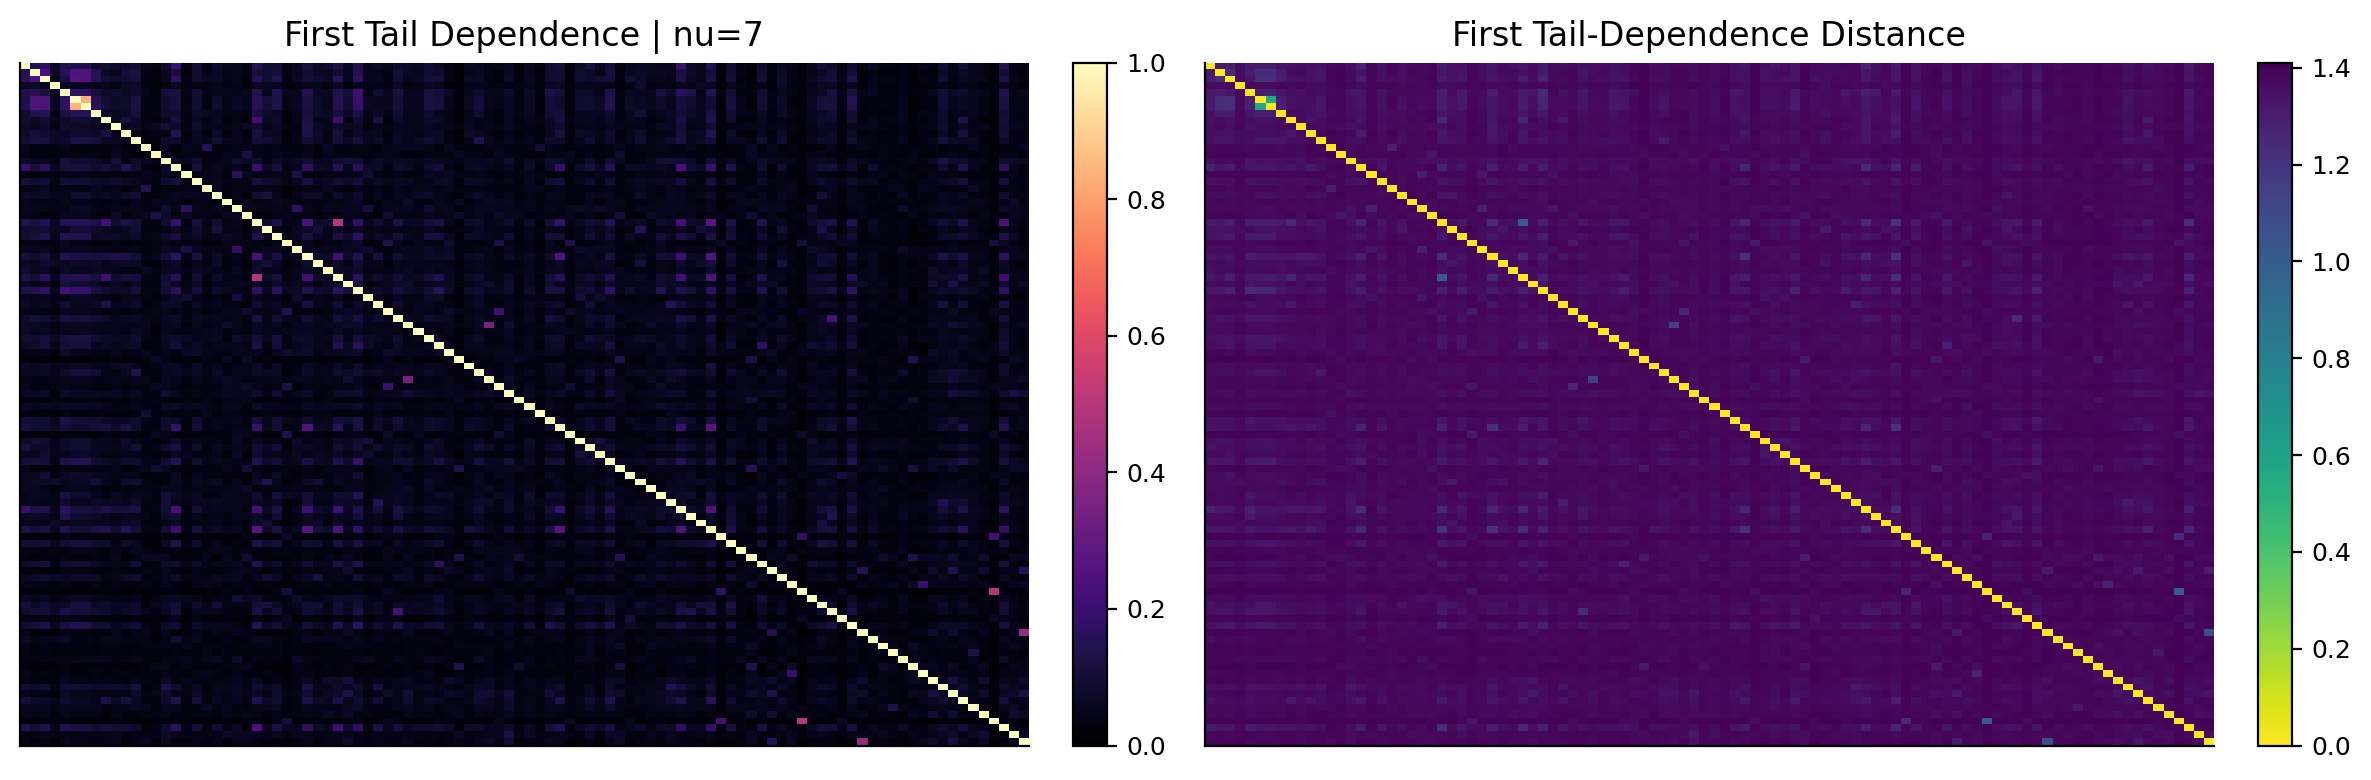

In [12]:
tri = np.triu_indices_from(tail_first, k=1)
display(nu_scores_first.to_frame().round(4))
display(
    pd.Series(
        {
            "selected nu": nu_first,
            "mean pairwise tail dependence": tail_first.to_numpy()[tri].mean(),
            "maximum pairwise tail dependence": tail_first.to_numpy()[tri].max(),
            "mean tail distance": tail_dist_first.to_numpy()[tri].mean(),
        },
        name="Student-t copula",
    ).to_frame().round(4)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
matrix_heatmap(axes[0], tail_first, f"First Tail Dependence | nu={nu_first:.0f}", "magma", 0.0, 1.0)
matrix_heatmap(axes[1], tail_dist_first, "First Tail-Dependence Distance", "viridis_r")
fig.tight_layout()
plt.show()


## Adjacency And Dense Networks


In [13]:
def dependence_adjacency(dependence):
    adjacency = dependence.clip(lower=0.0).copy()
    values = adjacency.to_numpy(copy=True)
    np.fill_diagonal(values, 0.0)
    return pd.DataFrame(values, index=adjacency.index, columns=adjacency.columns)


def dense_network(adjacency, distance):
    graph = nx.Graph()
    names = list(adjacency.index)
    graph.add_nodes_from(names)
    for i, left in enumerate(names):
        for j in range(i + 1, len(names)):
            right = names[j]
            graph.add_edge(
                left,
                right,
                weight=float(adjacency.iat[i, j]),
                distance=max(float(distance.iat[i, j]), 1e-8),
            )
    return graph


def draw_network(ax, graph, title, positions):
    strength = pd.Series(dict(graph.degree(weight="weight")), dtype=float)
    weights = np.asarray([attrs.get("weight", 0.0) for _, _, attrs in graph.edges(data=True)], dtype=float)
    high = max(float(weights.max()) if len(weights) else 1.0, 1e-12)
    dense = graph.number_of_edges() > 1000
    widths = 0.12 + (0.65 if dense else 2.1) * weights / high
    nx.draw_networkx_edges(
        graph,
        positions,
        ax=ax,
        width=widths,
        alpha=0.22 if dense else 0.70,
        edge_color=weights,
        edge_cmap=plt.cm.plasma,
        edge_vmin=0.0,
        edge_vmax=high,
    )
    nx.draw_networkx_nodes(
        graph,
        positions,
        ax=ax,
        node_size=[16 + 70 * strength.get(node, 0.0) / max(strength.max(), 1e-12) for node in graph.nodes()],
        node_color=[strength.get(node, 0.0) for node in graph.nodes()],
        cmap=plt.cm.viridis,
        edgecolors="white",
        linewidths=0.25,
        alpha=0.90,
    )
    ax.set_title(title)
    ax.set_axis_off()


In [14]:
corr_adjacency_first = dependence_adjacency(corr_first)
tail_adjacency_first = dependence_adjacency(tail_first)
corr_dense_first = dense_network(corr_adjacency_first, corr_dist_first)
tail_dense_first = dense_network(tail_adjacency_first, tail_dist_first)


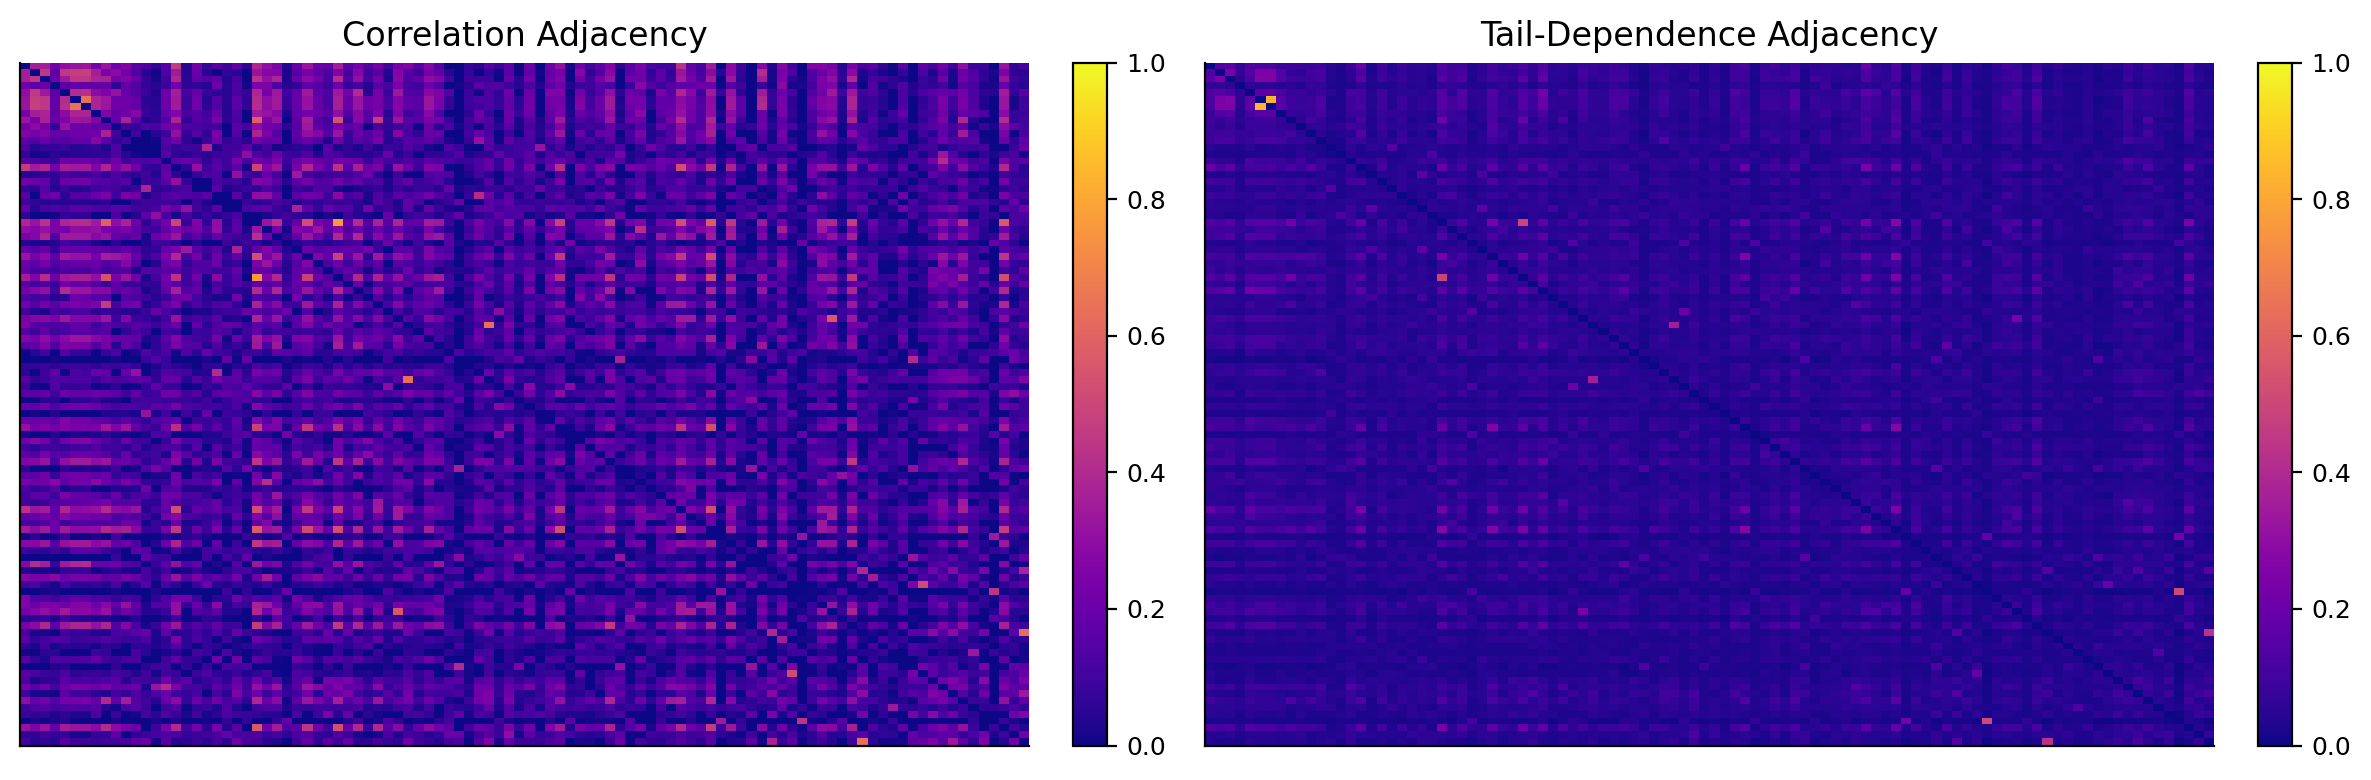

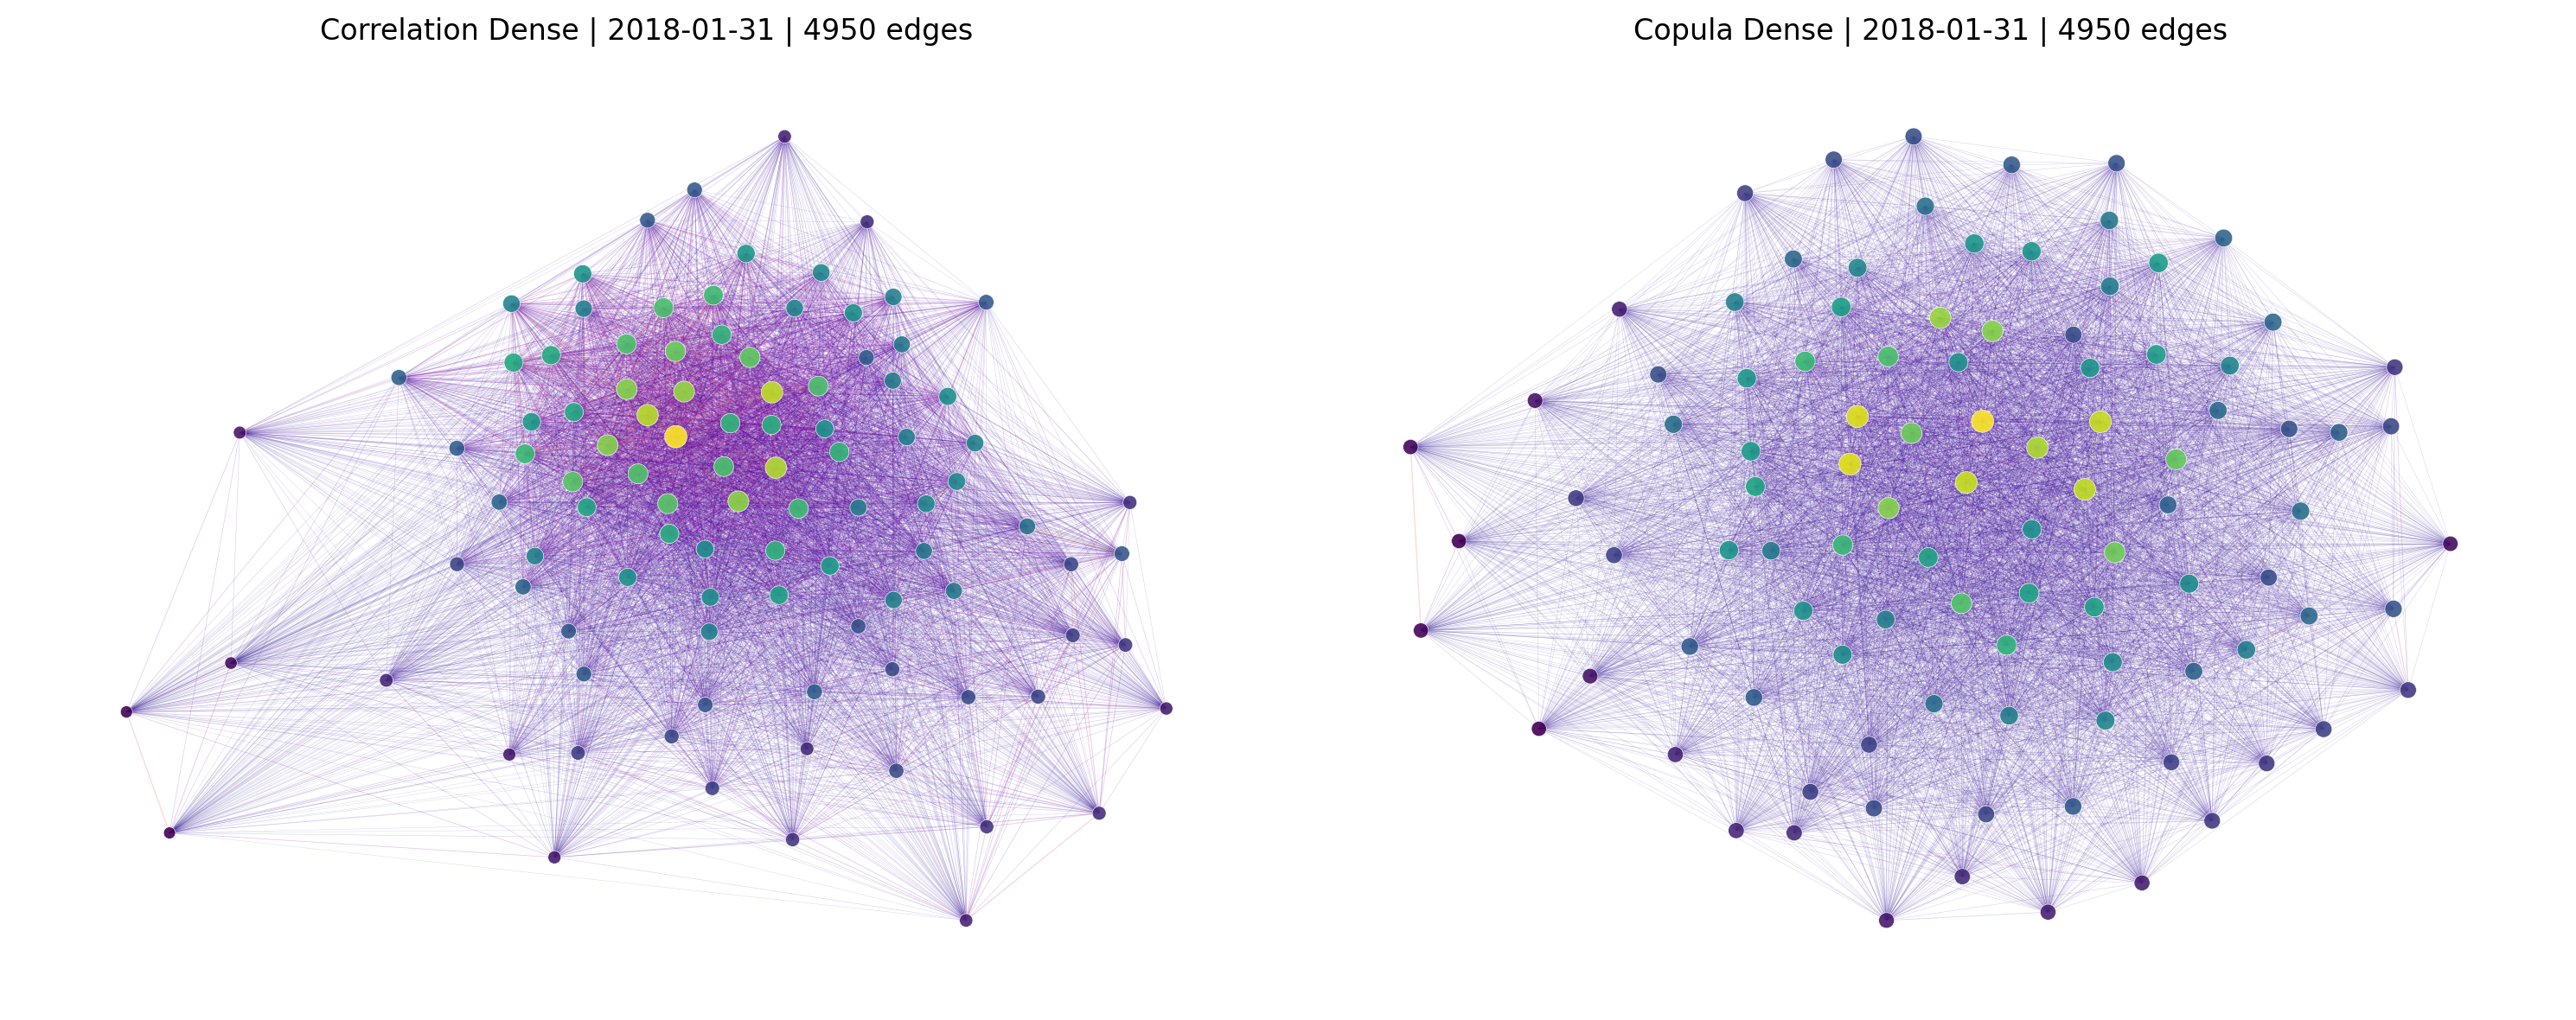

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
matrix_heatmap(axes[0], corr_adjacency_first, "Correlation Adjacency", "plasma", 0.0, 1.0)
matrix_heatmap(axes[1], tail_adjacency_first, "Tail-Dependence Adjacency", "plasma", 0.0, 1.0)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
draw_network(
    axes[0],
    corr_dense_first,
    f"Correlation Dense | {first_dt.date()} | {corr_dense_first.number_of_edges()} edges",
    nx.spring_layout(corr_dense_first, seed=17, weight="weight", iterations=45),
)
draw_network(
    axes[1],
    tail_dense_first,
    f"Copula Dense | {first_dt.date()} | {tail_dense_first.number_of_edges()} edges",
    nx.spring_layout(tail_dense_first, seed=17, weight="weight", iterations=45),
)
fig.tight_layout()
plt.show()


## PMFG And MST Filters


In [16]:
def pmfg_network(adjacency, distance):
    names = list(adjacency.index)
    graph = nx.Graph()
    graph.add_nodes_from(names)
    target_edges = max(0, 3 * (len(names) - 2))
    edges = []
    for i, left in enumerate(names):
        for j in range(i + 1, len(names)):
            right = names[j]
            edges.append(
                (float(adjacency.iat[i, j]), left, right, max(float(distance.iat[i, j]), 1e-8))
            )
    edges.sort(key=lambda row: row[0], reverse=True)

    embedding = None
    faces = []

    def refresh_faces(planar_embedding):
        seen, current = set(), []
        for left in planar_embedding.nodes():
            for right in planar_embedding.neighbors(left):
                if (left, right) in seen:
                    continue
                marked = set()
                current.append(set(planar_embedding.traverse_face(left, right, marked)))
                seen.update(marked)
        return current

    for strength, left, right, distance_value in edges:
        if graph.number_of_edges() >= target_edges:
            break
        if (
            embedding is not None
            and nx.has_path(graph, left, right)
            and not any(left in face and right in face for face in faces)
        ):
            continue
        graph.add_edge(left, right, weight=strength, distance=distance_value)
        planar, proposed = nx.check_planarity(graph, counterexample=False)
        if planar:
            embedding = proposed
            faces = refresh_faces(embedding)
        else:
            graph.remove_edge(left, right)

    edge_lookup = {
        frozenset((left, right)): (strength, left, right, distance_value)
        for strength, left, right, distance_value in edges
    }
    while graph.number_of_edges() < target_edges and faces:
        feasible = []
        for face in faces:
            for left, right in combinations(sorted(face), 2):
                if not graph.has_edge(left, right):
                    feasible.append(edge_lookup[frozenset((left, right))])
        if not feasible:
            break
        strength, left, right, distance_value = max(feasible, key=lambda row: row[0])
        graph.add_edge(left, right, weight=strength, distance=distance_value)
        planar, embedding = nx.check_planarity(graph, counterexample=False)
        if not planar:
            graph.remove_edge(left, right)
            break
        faces = refresh_faces(embedding)
    return graph


def mst_network(adjacency, distance):
    candidate = nx.Graph()
    names = list(adjacency.index)
    candidate.add_nodes_from(names)
    for i, left in enumerate(names):
        for j in range(i + 1, len(names)):
            right = names[j]
            candidate.add_edge(
                left,
                right,
                weight=float(adjacency.iat[i, j]),
                distance=max(float(distance.iat[i, j]), 1e-8),
            )
    return nx.minimum_spanning_tree(candidate, weight="distance")


In [17]:
corr_networks_first = {
    "PMFG": pmfg_network(corr_adjacency_first, corr_dist_first),
    "MST": mst_network(corr_adjacency_first, corr_dist_first),
}
copula_networks_first = {
    "PMFG": pmfg_network(tail_adjacency_first, tail_dist_first),
    "MST": mst_network(tail_adjacency_first, tail_dist_first),
}
network_sizes = pd.DataFrame(
    {
        "Correlation Dense": [corr_dense_first.number_of_nodes(), corr_dense_first.number_of_edges(), nx.check_planarity(corr_dense_first)[0]],
        "Correlation PMFG": [corr_networks_first["PMFG"].number_of_nodes(), corr_networks_first["PMFG"].number_of_edges(), nx.check_planarity(corr_networks_first["PMFG"])[0]],
        "Correlation MST": [corr_networks_first["MST"].number_of_nodes(), corr_networks_first["MST"].number_of_edges(), nx.check_planarity(corr_networks_first["MST"])[0]],
        "Copula Dense": [tail_dense_first.number_of_nodes(), tail_dense_first.number_of_edges(), nx.check_planarity(tail_dense_first)[0]],
        "Copula PMFG": [copula_networks_first["PMFG"].number_of_nodes(), copula_networks_first["PMFG"].number_of_edges(), nx.check_planarity(copula_networks_first["PMFG"])[0]],
        "Copula MST": [copula_networks_first["MST"].number_of_nodes(), copula_networks_first["MST"].number_of_edges(), nx.check_planarity(copula_networks_first["MST"])[0]],
    },
    index=["nodes", "edges", "planar"],
).T
display(network_sizes)


,nodes,edges,planar
Correlation Dense,100,4950,False
Correlation PMFG,100,294,True
Correlation MST,100,99,True
Copula Dense,100,4950,False
Copula PMFG,100,294,True
Copula MST,100,99,True


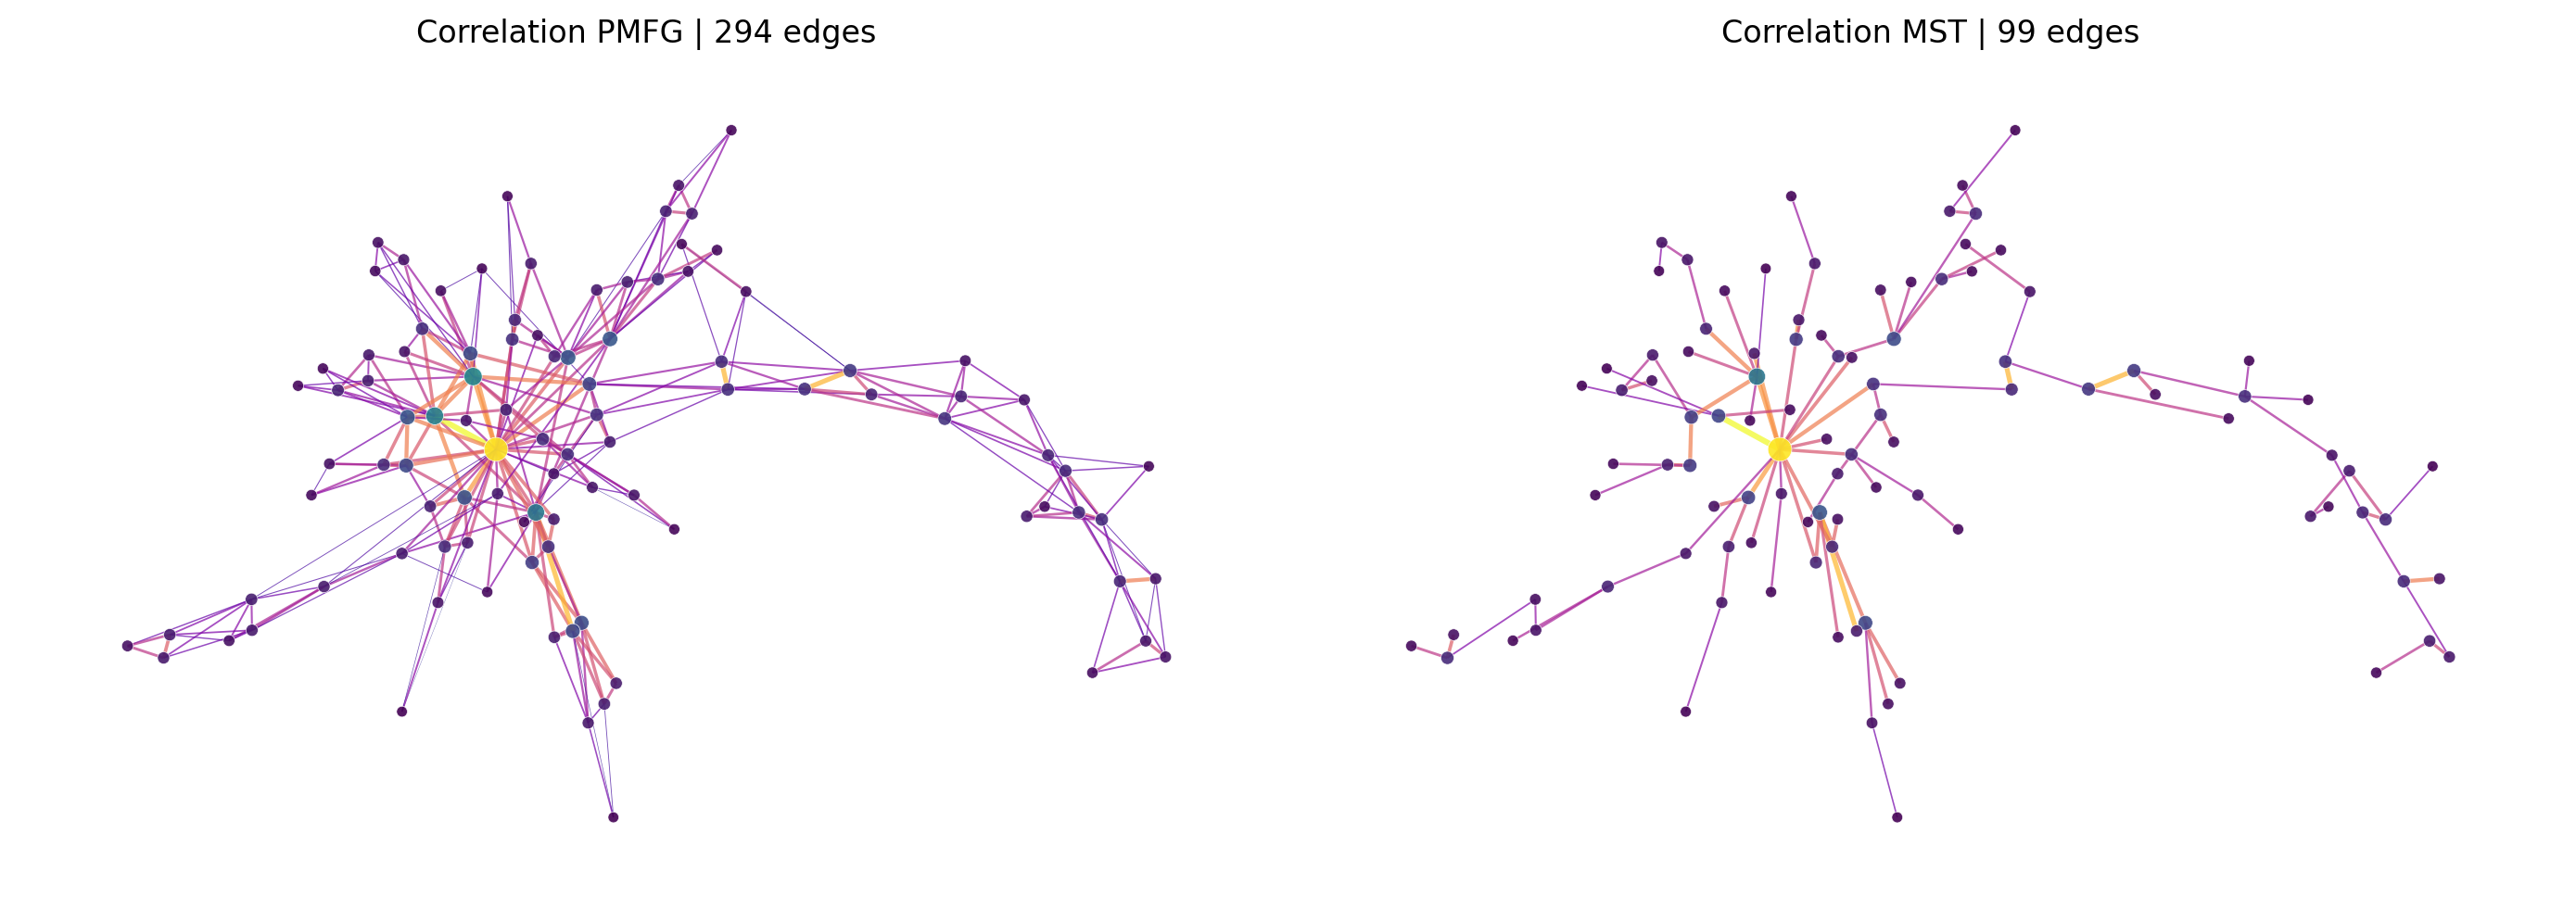

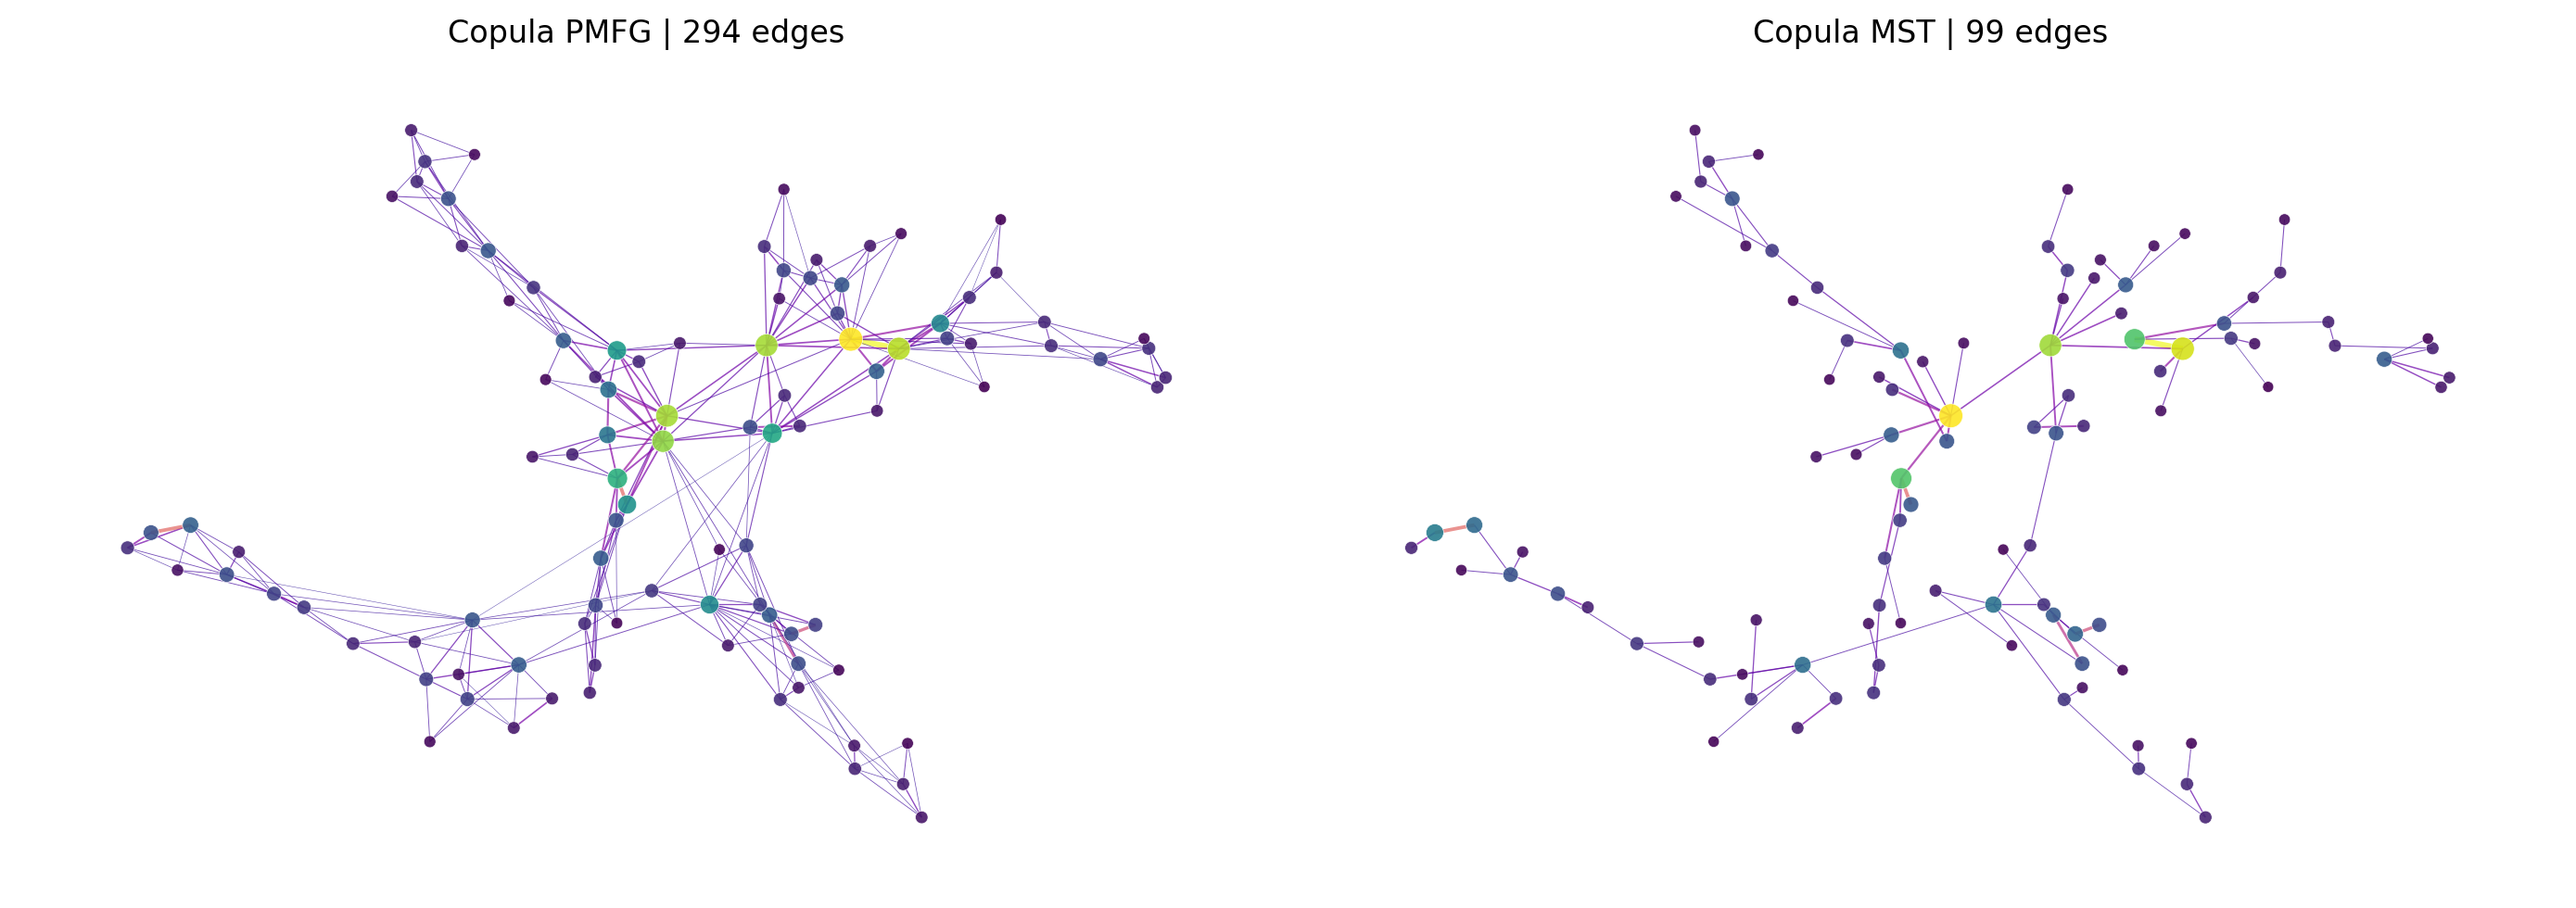

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
corr_positions = nx.spring_layout(corr_networks_first["PMFG"], seed=17, weight="weight")
for ax, (label, graph) in zip(axes, corr_networks_first.items()):
    draw_network(ax, graph, f"Correlation {label} | {graph.number_of_edges()} edges", corr_positions)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
copula_positions = nx.spring_layout(copula_networks_first["PMFG"], seed=17, weight="weight")
for ax, (label, graph) in zip(axes, copula_networks_first.items()):
    draw_network(ax, graph, f"Copula {label} | {graph.number_of_edges()} edges", copula_positions)
fig.tight_layout()
plt.show()


## Centrality


In [19]:
def scale_01(values):
    if isinstance(values, pd.DataFrame):
        return values.apply(scale_01)
    series = pd.Series(values, dtype=float)
    low, high = series.min(), series.max()
    if not np.isfinite(low) or not np.isfinite(high):
        return pd.Series(0.0, index=series.index)
    if high - low <= 1e-12:
        return pd.Series(0.5, index=series.index)
    return ((series - low) / (high - low)).clip(0.0, 1.0)


def combined_centrality(scores):
    return scale_01(scores.apply(scale_01).rank(pct=True).mean(axis=1))


def centrality_table(graph):
    nodes = list(graph.nodes())
    strength = pd.Series(dict(graph.degree(weight="weight")), dtype=float).reindex(nodes).fillna(0.0)
    try:
        eigenvector = nx.eigenvector_centrality_numpy(graph, weight="weight")
    except Exception:
        eigenvector = nx.eigenvector_centrality(graph, weight="weight", max_iter=1000)
    betweenness = nx.betweenness_centrality(
        graph,
        k=min(16, len(nodes)) if len(nodes) > 32 else None,
        seed=17,
        weight="distance",
        normalized=True,
    )
    closeness = nx.closeness_centrality(graph, distance="distance")
    output = pd.DataFrame(
        {
            "degree": scale_01(strength),
            "eigenvector": scale_01(pd.Series(eigenvector)),
            "betweenness": scale_01(pd.Series(betweenness)),
            "closeness": scale_01(pd.Series(closeness)),
        }
    ).reindex(nodes)
    output["combined"] = combined_centrality(output)
    return output


def frame_heatmap(ax, frame, title, cmap="viridis"):
    image = ax.imshow(frame.to_numpy(dtype=float), aspect="auto", cmap=cmap, vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(range(len(frame.columns)))
    ax.set_xticklabels(frame.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(frame.index)))
    ax.set_yticklabels(frame.index.astype(str), fontsize=6)
    ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


,correlation pmfg,correlation mst,copula pmfg,copula mst
0,AMAT,AMAT,MSFT,ADBE
1,MCHP,MCHP,SWKS,MCHP
2,LRCX,TXN,MCHP,GOOG
3,GOOG,MU,ADBE,GOOGL
4,TXN,TTWO,GOOGL,MSFT


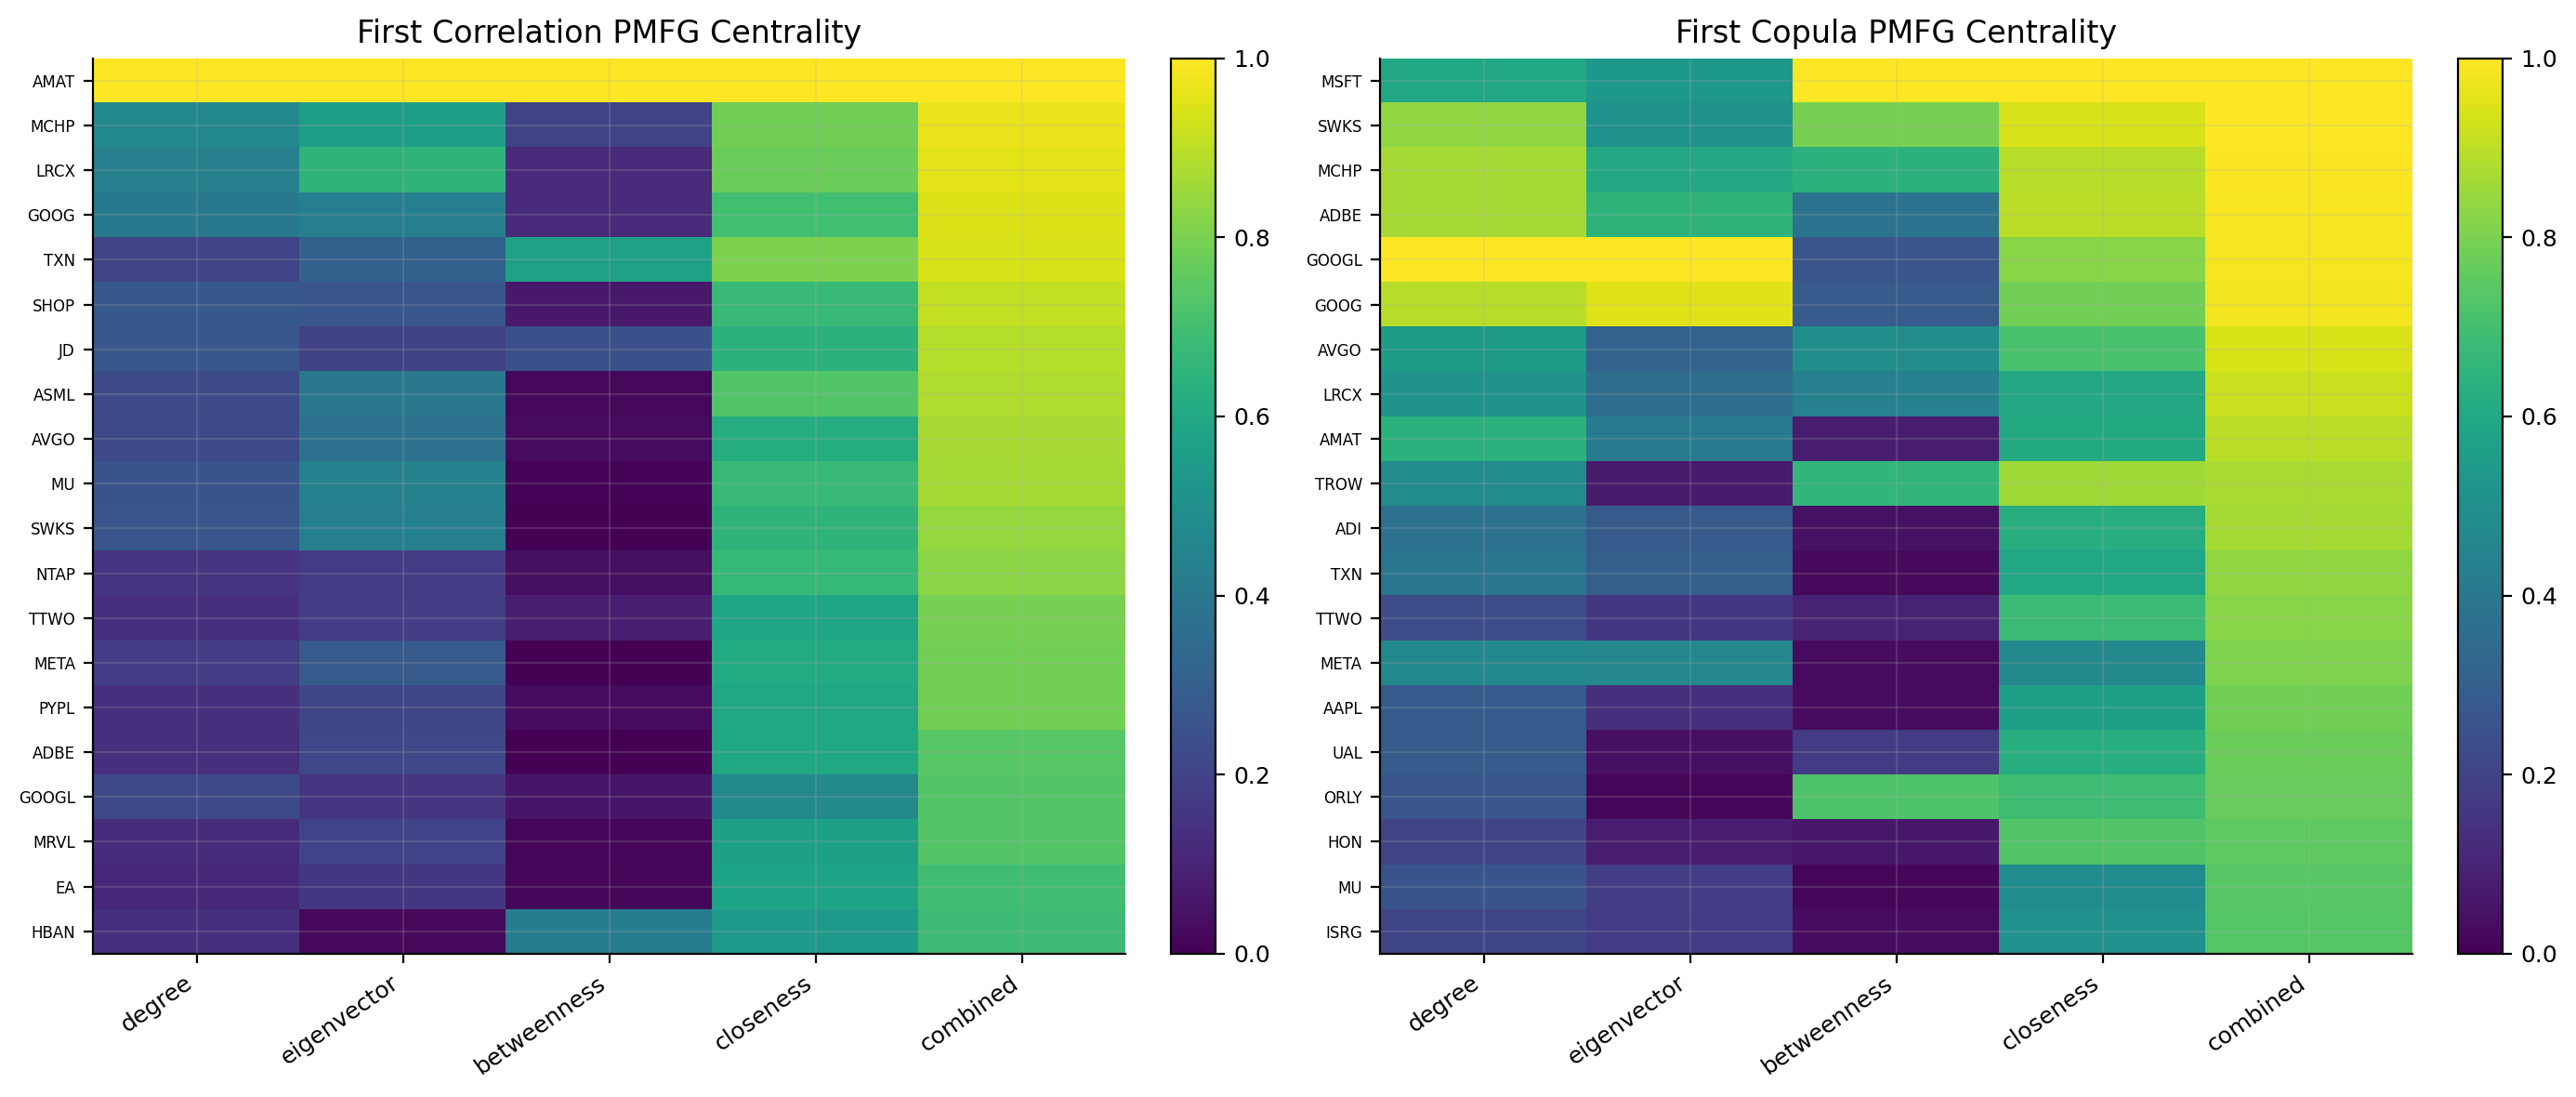

In [20]:
first_centralities = {
    ("correlation", "pmfg"): centrality_table(corr_networks_first["PMFG"]),
    ("correlation", "mst"): centrality_table(corr_networks_first["MST"]),
    ("copula", "pmfg"): centrality_table(copula_networks_first["PMFG"]),
    ("copula", "mst"): centrality_table(copula_networks_first["MST"]),
}
first_central_summary = pd.DataFrame(
    {
        f"{dependence} {network}": scores["combined"].sort_values(ascending=False).head(5).index.tolist()
        for (dependence, network), scores in first_centralities.items()
    }
)
display(first_central_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, key in zip(axes, [("correlation", "pmfg"), ("copula", "pmfg")]):
    shown = first_centralities[key].sort_values("combined", ascending=False).head(20)
    frame_heatmap(ax, shown, f"First {key[0].title()} PMFG Centrality")
fig.tight_layout()
plt.show()


In [21]:
correlation_store = {}
for dt in rebalance_dates:
    names = list(universe_by_date[dt]["tickers"])
    window = clean_window(ret_d.loc[:dt, names].tail(lookback))
    if window.shape[0] < min_obs or window.shape[1] < 50:
        continue
    corr = shrink_corr(window)
    distance = corr_distance(corr)
    adjacency = dependence_adjacency(corr)
    graphs = {
        "pmfg": pmfg_network(adjacency, distance),
        "mst": mst_network(adjacency, distance),
    }
    correlation_store[pd.Timestamp(dt)] = {
        "window": window,
        "corr": corr,
        "distance": distance,
        "adjacency": adjacency,
        "graphs": graphs,
        "centralities": {name: centrality_table(graph) for name, graph in graphs.items()},
    }


In [22]:
display(
    pd.DataFrame(
        {
            "dates": [len(correlation_store)],
            "average PMFG edges": [np.mean([row["graphs"]["pmfg"].number_of_edges() for row in correlation_store.values()])],
            "average MST edges": [np.mean([row["graphs"]["mst"].number_of_edges() for row in correlation_store.values()])],
        },
        index=["rolling correlation centralities"],
    ).round(1)
)


,dates,average PMFG edges,average MST edges
rolling correlation centralities,33,294.0,99.0


In [23]:
copula_store = {}
for dt, correlation_record in correlation_store.items():
    window = correlation_record["window"]
    pseudo = pseudo_observations(window)
    rho_t = kendall_to_t_copula_corr(pseudo)
    nu, _ = select_t_copula_nu(pseudo)
    tail = student_t_tail_dependence(rho_t, nu)
    distance = dependence_to_distance(tail)
    adjacency = dependence_adjacency(tail)
    graphs = {
        "pmfg": pmfg_network(adjacency, distance),
        "mst": mst_network(adjacency, distance),
    }
    copula_store[dt] = {
        "window": window,
        "tail": tail,
        "distance": distance,
        "adjacency": adjacency,
        "nu": nu,
        "graphs": graphs,
        "centralities": {name: centrality_table(graph) for name, graph in graphs.items()},
    }

network_store = {}
for dt in sorted(copula_store):
    network_store[dt] = {
        "window": correlation_store[dt]["window"],
        "corr": correlation_store[dt]["corr"],
        "tail": copula_store[dt]["tail"],
        "nu": copula_store[dt]["nu"],
        "centralities": {
            ("correlation", "pmfg"): correlation_store[dt]["centralities"]["pmfg"],
            ("correlation", "mst"): correlation_store[dt]["centralities"]["mst"],
            ("copula", "pmfg"): copula_store[dt]["centralities"]["pmfg"],
            ("copula", "mst"): copula_store[dt]["centralities"]["mst"],
        },
    }
model_dates = pd.DatetimeIndex(sorted(network_store))


In [24]:
copula_diagnostics = pd.DataFrame(
    {
        "nu": {dt: record["nu"] for dt, record in copula_store.items()},
        "mean tail dependence": {
            dt: float(np.mean(record["tail"].to_numpy()[np.triu_indices_from(record["tail"], k=1)]))
            for dt, record in copula_store.items()
        },
        "PMFG edges": {dt: record["graphs"]["pmfg"].number_of_edges() for dt, record in copula_store.items()},
    }
)
display(copula_diagnostics.round(4))

latest_dt = model_dates[-1]
default_centrality_setup = ("copula", "pmfg", "combined")
latest_centrality = network_store[latest_dt]["centralities"][default_centrality_setup[:2]]
display(pd.DataFrame({"centrality preview": ["Latest copula PMFG combined centrality"]}))
display(latest_centrality.sort_values("combined", ascending=False).head(20).round(3))
display(latest_centrality.sort_values("combined", ascending=True).head(20).round(3))


,nu,mean tail dependence,PMFG edges
2018-01-31,7.0,0.0536,294
2018-04-30,7.0,0.0775,294
2018-07-31,7.0,0.0776,294
2018-10-31,7.0,0.0855,294
2019-01-31,7.0,0.1110,294
2019-04-30,7.0,0.0898,294
2019-07-31,7.0,0.0960,294
2019-10-31,7.0,0.1055,294
2020-01-31,7.0,0.0835,294
2020-04-30,4.0,0.2322,294


,centrality preview
0,Latest copula PMFG combined centrality


,degree,eigenvector,betweenness,closeness,combined
LRCX,1.000,1.000,0.986,0.949,1.000
ADI,0.975,0.745,0.515,0.801,0.981
NVDA,0.787,0.305,1.000,1.000,0.967
ON,0.669,0.700,0.386,0.727,0.937
AMAT,0.611,0.700,0.089,0.802,0.910
NXPI,0.786,0.585,0.418,0.605,0.902
MU,0.573,0.479,0.047,0.795,0.875
KLAC,0.754,0.797,0.022,0.654,0.867
COIN,0.649,0.037,0.624,0.755,0.864
CRWD,0.828,0.086,0.142,0.689,0.859


,degree,eigenvector,betweenness,closeness,combined
EA,0.000,0.000,0.00,0.000,0.000
CME,0.021,0.000,0.00,0.106,0.016
REGN,0.072,0.000,0.00,0.024,0.043
VRTX,0.095,0.000,0.00,0.094,0.071
MDLZ,0.077,0.001,0.00,0.125,0.076
RIVN,0.045,0.001,0.00,0.265,0.101
ORLY,0.138,0.001,0.00,0.114,0.114
BKNG,0.084,0.001,0.00,0.210,0.120
SBUX,0.046,0.002,0.00,0.216,0.120
MELI,0.035,0.001,0.00,0.302,0.125


## Network Portfolios


In [25]:
def capped_normalize(raw, max_weight=0.10):
    weights = pd.Series(raw, dtype=float).clip(lower=0.0)
    if weights.sum() <= 1e-12:
        weights[:] = 1.0
    weights = weights / weights.sum()
    for _ in range(50):
        over = weights > max_weight + 1e-12
        if not over.any():
            break
        extra = float((weights[over] - max_weight).sum())
        weights[over] = max_weight
        room = (max_weight - weights[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        weights.loc[room.index] += extra * room / room.sum()
    return weights / weights.sum()


def central_peripheral_weights(score, returns, n_stocks=20, max_weight=0.10):
    available = pd.Series(score, dtype=float).reindex(returns.columns).dropna()
    chosen = available.sort_values(ascending=False).head(n_stocks).index
    return capped_normalize(pd.Series(1.0, index=chosen), max_weight=max_weight)


def network_score(
    peripheral,
    returns,
    momentum_window=126,
    volatility_window=126,
    drawdown_window=252,
    periphery_weight=0.35,
    momentum_weight=0.35,
    volatility_weight=-0.20,
    drawdown_weight=-0.10,
):
    window = clean_window(returns)
    periphery = scale_01(pd.Series(peripheral).reindex(window.columns).fillna(0.0))
    momentum = (1.0 + window.tail(momentum_window)).prod() - 1.0
    volatility = window.tail(volatility_window).std() * np.sqrt(252.0)
    nav = (1.0 + window.tail(drawdown_window)).cumprod()
    drawdown = (nav / nav.cummax() - 1.0).min().abs()
    return (
        periphery_weight * periphery
        + momentum_weight * scale_01(momentum)
        + volatility_weight * scale_01(volatility)
        + drawdown_weight * scale_01(drawdown)
    )


def network_diversifier_weights(score, returns, n_stocks=25, max_weight=0.10):
    selected = pd.Series(score).sort_values(ascending=False).head(n_stocks)
    volatility = returns[selected.index].tail(126).std().clip(lower=1e-8)
    positive_score = selected - min(float(selected.min()), 0.0) + 1e-6
    return capped_normalize(positive_score / volatility, max_weight=max_weight)


def pairwise_corr_for_weights(returns, weights, lookback=126):
    rows = {}
    for dt, row in weights.iterrows():
        active = row[row > 1e-6].index.intersection(returns.columns)
        window = returns.loc[:dt, active].tail(lookback).dropna(axis=0, how="any")
        if len(active) < 2 or len(window) < 20:
            rows[dt] = np.nan
            continue
        corr = window.corr().to_numpy()
        rows[dt] = float(np.nanmean(corr[np.triu_indices_from(corr, k=1)]))
    return pd.Series(rows)


In [26]:
comparison_weight_rows = {}

for dt in model_dates:
    record = network_store[dt]
    for (dependence, network_type), scores in record["centralities"].items():
        for measure in ["degree", "eigenvector", "betweenness", "closeness", "combined"]:
            central = scale_01(scores[measure])
            for direction, selection_score in {"central": central, "peripheral": 1.0 - central}.items():
                name = f"{direction}|{dependence}|{network_type}|{measure}"
                comparison_weight_rows.setdefault(name, {})[dt] = central_peripheral_weights(
                    selection_score, record["window"], 20, w_max
                )

comparison_weights = {
    name: pd.DataFrame.from_dict(rows, orient="index").fillna(0.0)
    for name, rows in comparison_weight_rows.items()
}

candidate_index = (
    model_dates.intersection(w_equal.index).intersection(w_minvar.index).intersection(w_hrp.index)
)
comparison_cols = sorted(set().union(*(set(frame.columns) for frame in comparison_weights.values())))
comparison_weights = {
    name: frame.reindex(index=candidate_index, columns=comparison_cols).fillna(0.0)
    for name, frame in comparison_weights.items()
}
comparison_results = run_many_weights_backtests(
    comparison_weights,
    returns=ret_d.reindex(columns=comparison_cols).fillna(0.0),
    cost_bps=cost_bps,
    w_min=w_min,
    w_max=w_max,
    long_only=True,
    weight_timing="next_close",
    rf_daily=rf_daily,
)

display(
    pd.DataFrame(
        {
            "candidate strategies": [len(comparison_weights)],
            "rolling selector lookback": ["past 2 years"],
            "early fallback": ["copula PMFG combined"],
            "stability gate": ["use rolling only if trailing Sharpe >= 0.50"],
        }
    )
)


,candidate strategies,rolling selector lookback,early fallback,stability gate
0,40,past 2 years,copula PMFG combined,use rolling only if trailing Sharpe >= 0.50


,central_choice,central_sharpe,central_source,peripheral_choice,peripheral_sharpe,peripheral_source,network_choice,network_sharpe,network_source
date,,,,,,,,,
2023-07-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|mst|eigenvector,-0.307436,train-fixed,peripheral|correlation|mst|eigenvector,-0.307436,train-fixed
2023-10-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|mst|eigenvector,-0.501663,train-fixed,peripheral|correlation|mst|eigenvector,-0.501663,train-fixed
2024-01-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|mst|eigenvector,0.201448,train-fixed,peripheral|correlation|mst|eigenvector,0.201448,train-fixed
2024-04-30,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,0.589936,rolling,peripheral|copula|pmfg|betweenness,0.589936,rolling
2024-07-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,0.825433,rolling,peripheral|copula|pmfg|betweenness,0.825433,rolling
2024-10-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,1.224651,rolling,peripheral|copula|pmfg|betweenness,1.224651,rolling
2025-01-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,1.321872,rolling,peripheral|copula|pmfg|betweenness,1.321872,rolling
2025-04-30,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,0.960527,rolling,peripheral|copula|pmfg|betweenness,0.960527,rolling
2025-07-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,1.008173,rolling,peripheral|copula|pmfg|betweenness,1.008173,rolling


,Most Central 20,Most Peripheral 20,Network Diversifier
central|copula|pmfg|combined,32,0,0
peripheral|copula|pmfg|combined,0,9,9
peripheral|copula|pmfg|betweenness,0,9,9
peripheral|correlation|mst|eigenvector,0,8,8
peripheral|correlation|mst|degree,0,3,3
peripheral|correlation|pmfg|betweenness,0,2,2
peripheral|correlation|pmfg|closeness,0,1,1


,average holdings,maximum weight
Most Central 20,20.0,0.0500
Most Peripheral 20,20.0,0.0500
Network Diversifier,25.0,0.0978


,Most Central 20,Most Peripheral 20,Network Diversifier
MSFT,0.05,0.00,0.0616
CME,0.00,0.00,0.0586
COST,0.00,0.00,0.0568
WMT,0.00,0.00,0.0546
ORLY,0.00,0.00,0.0546
CSCO,0.00,0.05,0.0537
LRCX,0.05,0.00,0.0000
GOOGL,0.00,0.05,0.0351
AMAT,0.05,0.00,0.0000
AVGO,0.05,0.00,0.0000


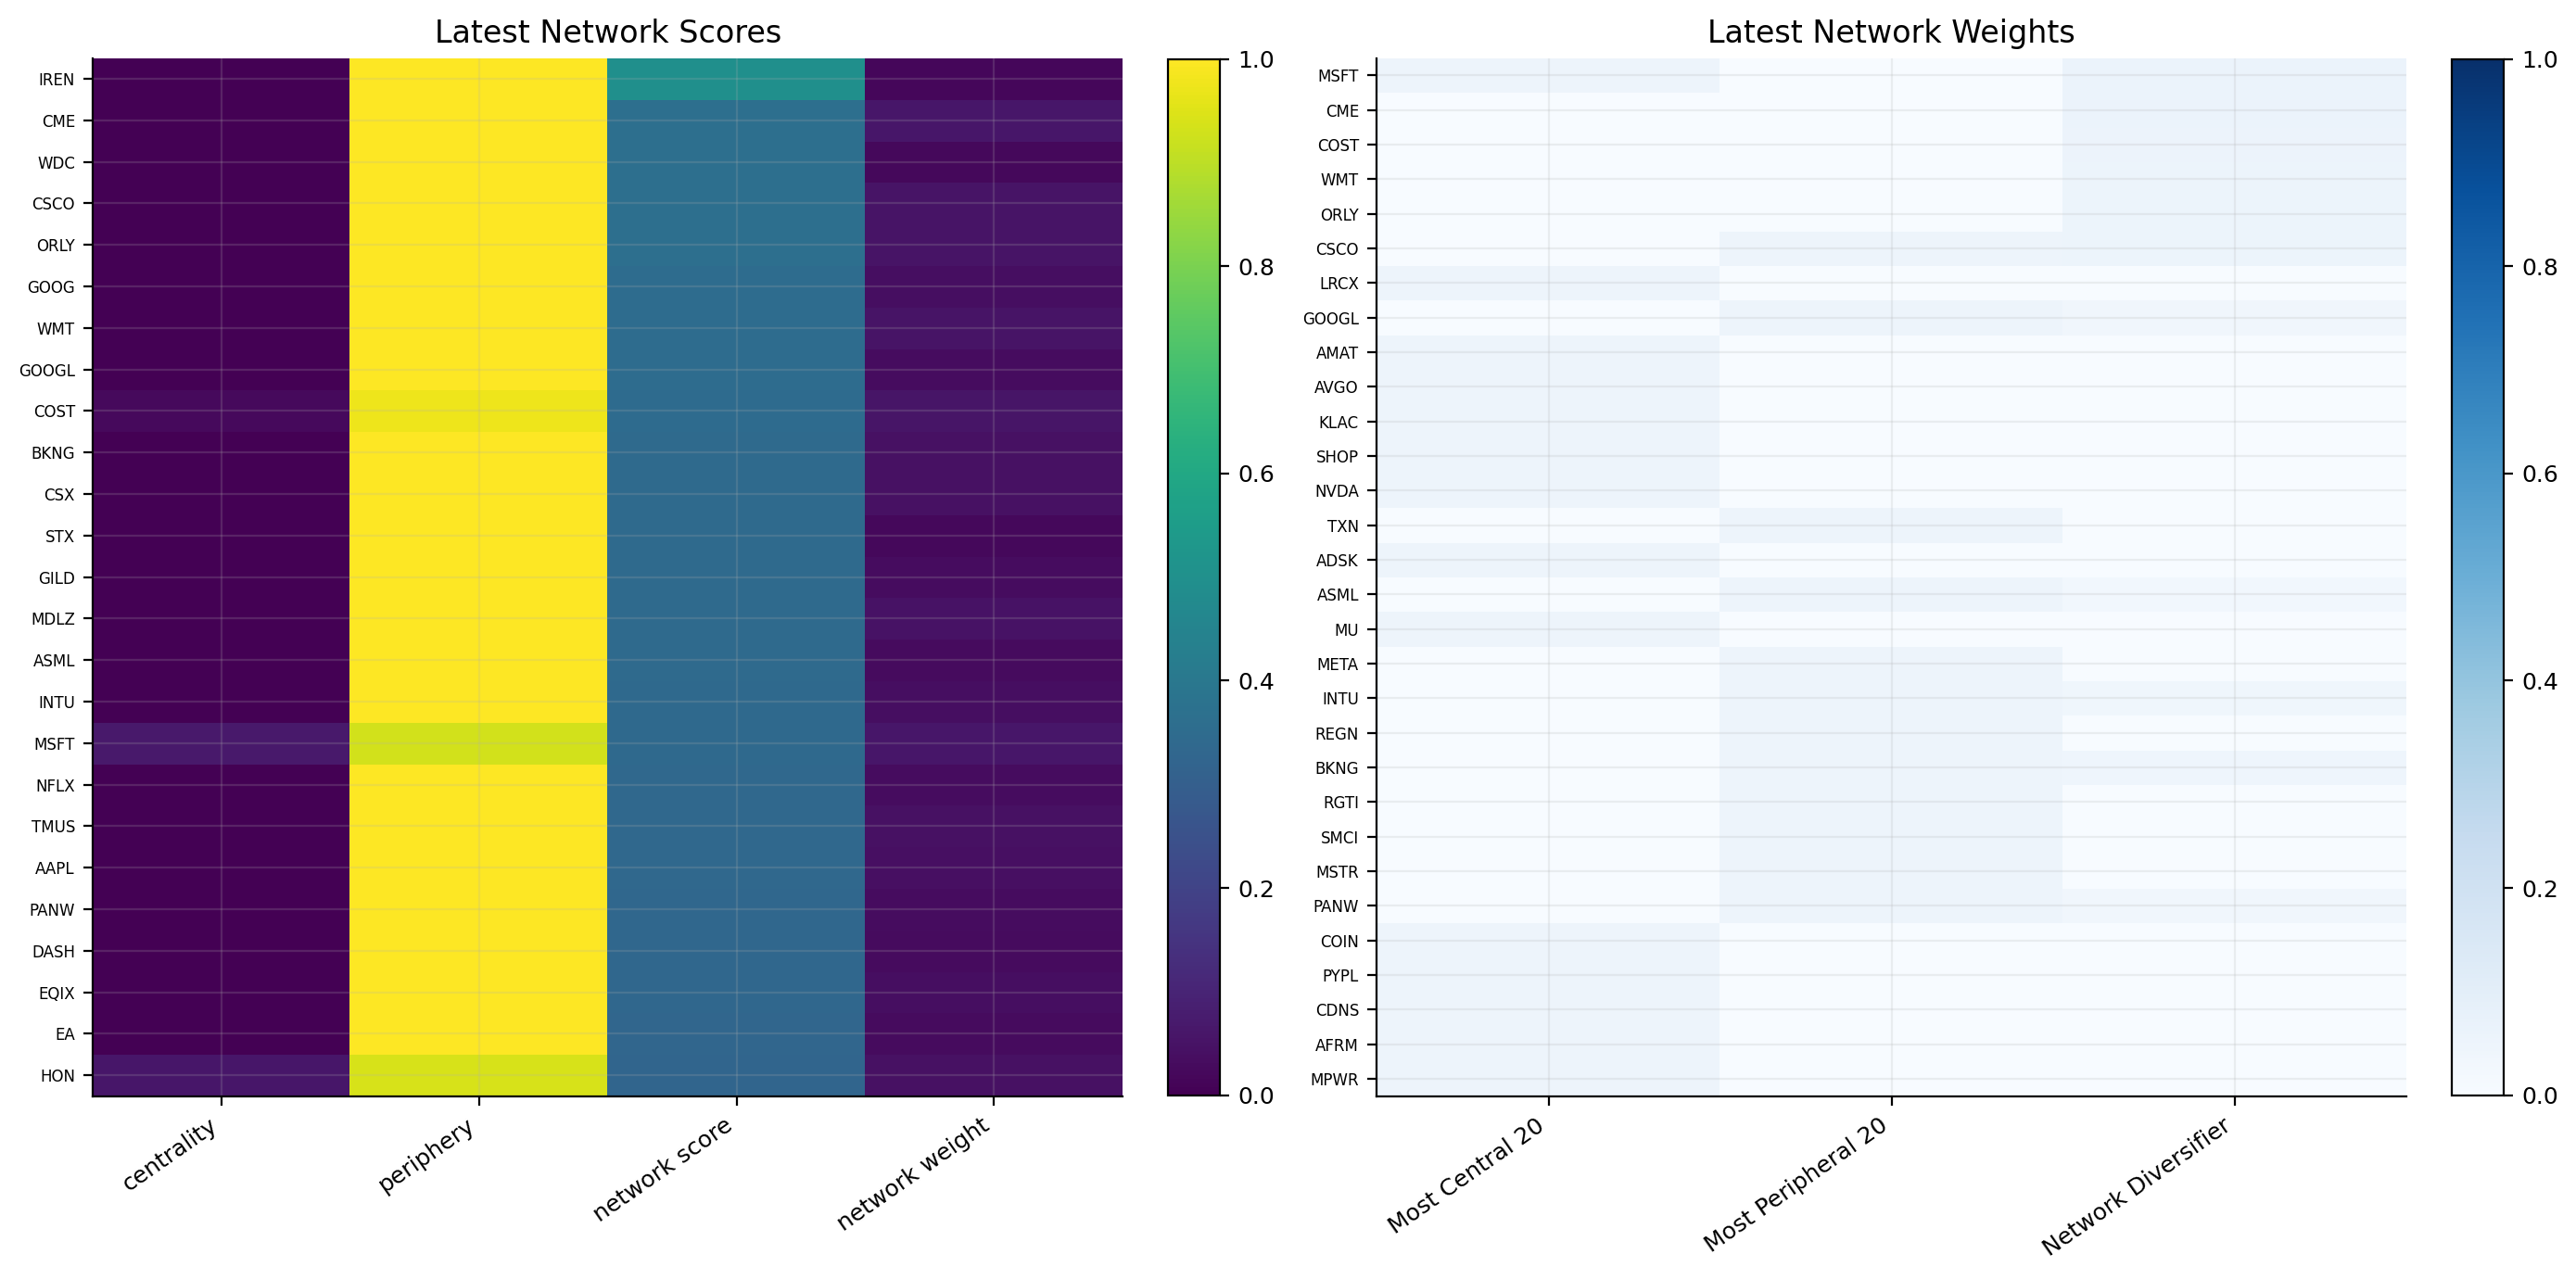

In [27]:
def parse_choice_name(name):
    direction, dependence, network_type, measure = name.split("|")
    return direction, dependence, network_type, measure


def rolling_choice(results, dt, direction, lookback_years=2, min_obs=252):
    fallback = f"{direction}|copula|pmfg|combined"
    start = pd.Timestamp(dt) - pd.DateOffset(years=lookback_years)
    rows = []
    for name, result in results.items():
        if not name.startswith(f"{direction}|"):
            continue
        returns_window = result.net_returns.loc[
            (result.net_returns.index >= start) & (result.net_returns.index < dt)
        ].dropna()
        if len(returns_window) < min_obs:
            continue
        nav_window = (1.0 + returns_window).cumprod()
        metrics = performance_metrics(
            returns_window,
            nav_window,
            rf_daily=rf_daily,
            annualization=annualization,
        )
        turnover_window = result.turnover.loc[
            (result.turnover.index >= start) & (result.turnover.index < dt)
        ].dropna()
        rows.append(
            {
                "name": name,
                "Sharpe": metrics["Sharpe"],
                "Max Drawdown": metrics["Max Drawdown"],
                "Calmar": metrics["Calmar"],
                "turnover": float(turnover_window.mean()) if len(turnover_window) else np.nan,
            }
        )

    if not rows:
        return fallback, {"Sharpe": np.nan, "Max Drawdown": np.nan, "source": "fallback"}

    table = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
    if table.empty:
        return fallback, {"Sharpe": np.nan, "Max Drawdown": np.nan, "source": "fallback"}

    best = table.sort_values(
        ["Sharpe", "Max Drawdown", "turnover"],
        ascending=[False, False, True],
    ).iloc[0]
    return best["name"], {
        "Sharpe": float(best["Sharpe"]),
        "Max Drawdown": float(best["Max Drawdown"]),
        "source": "rolling",
    }


def train_choice(results, direction, train_end, min_obs=252):
    fallback = f"{direction}|copula|pmfg|combined"
    rows = []
    for name, result in results.items():
        if not name.startswith(f"{direction}|"):
            continue
        returns_window = result.net_returns.loc[result.net_returns.index < train_end].dropna()
        if len(returns_window) < min_obs:
            continue
        nav_window = (1.0 + returns_window).cumprod()
        metrics = performance_metrics(
            returns_window,
            nav_window,
            rf_daily=rf_daily,
            annualization=annualization,
        )
        turnover_window = result.turnover.loc[result.turnover.index < train_end].dropna()
        rows.append(
            {
                "name": name,
                "Sharpe": metrics["Sharpe"],
                "Max Drawdown": metrics["Max Drawdown"],
                "turnover": float(turnover_window.mean()) if len(turnover_window) else np.nan,
            }
        )
    if not rows:
        return fallback
    table = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
    if table.empty:
        return fallback
    return table.sort_values(["Sharpe", "Max Drawdown", "turnover"], ascending=[False, False, True]).iloc[0]["name"]


selector_train_end = candidate_index[min(8, len(candidate_index) - 1)]
central_fixed_choice = "central|copula|pmfg|combined"
peripheral_train_choice = train_choice(comparison_results, "peripheral", selector_train_end)


def stability_gated_choice(results, dt, direction, train_selection, threshold=0.50):
    if pd.Timestamp(dt) <= selector_train_end:
        return f"{direction}|copula|pmfg|combined", {"Sharpe": np.nan, "source": "fallback"}
    rolling_name, rolling_info = rolling_choice(results, dt, direction)
    if not np.isfinite(rolling_info["Sharpe"]) or rolling_info["Sharpe"] < threshold:
        return train_selection, {"Sharpe": rolling_info["Sharpe"], "source": "train-fixed"}
    return rolling_name, rolling_info


selection_records = []
w_central_rows, w_peripheral_rows, w_network_rows = {}, {}, {}
score_rows = {}

for dt in candidate_index:
    central_choice = central_fixed_choice
    central_info = {"Sharpe": np.nan, "source": "fixed"}
    peripheral_choice, peripheral_info = stability_gated_choice(
        comparison_results, dt, "peripheral", peripheral_train_choice
    )
    network_choice, network_info = stability_gated_choice(
        comparison_results, dt, "peripheral", peripheral_train_choice
    )
    selection_records.append(
        {
            "date": dt,
            "central_choice": central_choice,
            "central_sharpe": central_info["Sharpe"],
            "central_source": central_info["source"],
            "peripheral_choice": peripheral_choice,
            "peripheral_sharpe": peripheral_info["Sharpe"],
            "peripheral_source": peripheral_info["source"],
            "network_choice": network_choice,
            "network_sharpe": network_info["Sharpe"],
            "network_source": network_info["source"],
        }
    )

    record = network_store[dt]

    _, dependence, network_type, measure = parse_choice_name(central_choice)
    centrality = record["centralities"][(dependence, network_type)]
    central_score = scale_01(centrality[measure])
    w_central_rows[dt] = central_peripheral_weights(central_score, record["window"], 20, w_max)

    _, dependence, network_type, measure = parse_choice_name(peripheral_choice)
    centrality = record["centralities"][(dependence, network_type)]
    periphery_score = 1.0 - scale_01(centrality[measure])
    w_peripheral_rows[dt] = central_peripheral_weights(periphery_score, record["window"], 20, w_max)

    _, dependence, network_type, measure = parse_choice_name(network_choice)
    centrality = record["centralities"][(dependence, network_type)]
    periphery_score = 1.0 - scale_01(centrality[measure])
    score = network_score(periphery_score, record["window"])
    score_rows[dt] = score
    w_network_rows[dt] = network_diversifier_weights(score, record["window"], 25, w_max)

selection_history = pd.DataFrame(selection_records).set_index("date")
w_central = pd.DataFrame.from_dict(w_central_rows, orient="index").fillna(0.0)
w_peripheral = pd.DataFrame.from_dict(w_peripheral_rows, orient="index").fillna(0.0)
w_network = pd.DataFrame.from_dict(w_network_rows, orient="index").fillna(0.0)

latest_dt = candidate_index[-1]
latest_network_choice = selection_history.loc[latest_dt, "network_choice"]
_, latest_dependence, latest_network_type, latest_measure = parse_choice_name(latest_network_choice)
latest_centrality = network_store[latest_dt]["centralities"][(latest_dependence, latest_network_type)]
latest_central_score = scale_01(latest_centrality[latest_measure])
latest_scores = pd.concat(
    {
        "centrality": latest_central_score,
        "periphery": 1.0 - latest_central_score,
        "network score": score_rows[latest_dt],
        "network weight": w_network.loc[latest_dt],
    },
    axis=1,
).fillna(0.0)
latest_network_weights = pd.concat(
    {
        "Most Central 20": w_central.loc[latest_dt],
        "Most Peripheral 20": w_peripheral.loc[latest_dt],
        "Network Diversifier": w_network.loc[latest_dt],
    },
    axis=1,
).fillna(0.0)
selection_counts = pd.concat(
    {
        "Most Central 20": selection_history["central_choice"].value_counts(),
        "Most Peripheral 20": selection_history["peripheral_choice"].value_counts(),
        "Network Diversifier": selection_history["network_choice"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)
construction_check = pd.DataFrame(
    {
        "average holdings": [(w_central > 0).sum(axis=1).mean(), (w_peripheral > 0).sum(axis=1).mean(), (w_network > 0).sum(axis=1).mean()],
        "maximum weight": [w_central.max(axis=1).max(), w_peripheral.max(axis=1).max(), w_network.max(axis=1).max()],
    },
    index=["Most Central 20", "Most Peripheral 20", "Network Diversifier"],
)
display(selection_history.tail(10))
display(selection_counts)
display(construction_check.round(4))
display(latest_network_weights.loc[latest_network_weights.max(axis=1).sort_values(ascending=False).head(30).index].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
frame_heatmap(axes[0], latest_scores.sort_values("network score", ascending=False).head(25), "Latest Network Scores")
frame_heatmap(axes[1], latest_network_weights.loc[latest_network_weights.max(axis=1).sort_values(ascending=False).head(30).index], "Latest Network Weights", cmap="Blues")
fig.tight_layout()
plt.show()


## Backtest Results


In [28]:
common_index = (
    w_network.index.intersection(w_equal.index).intersection(w_minvar.index).intersection(w_hrp.index)
)
common_cols = sorted(
    set(w_equal.columns)
    | set(w_minvar.columns)
    | set(w_hrp.columns)
    | set(w_central.columns)
    | set(w_peripheral.columns)
    | set(w_network.columns)
)
weights = {
    "Equal Weight": w_equal.reindex(index=common_index, columns=common_cols).fillna(0.0),
    "MinVar": w_minvar.reindex(index=common_index, columns=common_cols).fillna(0.0),
    "HRP": w_hrp.reindex(index=common_index, columns=common_cols).fillna(0.0),
    "Most Central 20": w_central.reindex(index=common_index, columns=common_cols).fillna(0.0),
    "Most Peripheral 20": w_peripheral.reindex(index=common_index, columns=common_cols).fillna(0.0),
    "Network Diversifier": w_network.reindex(index=common_index, columns=common_cols).fillna(0.0),
}
returns_for_backtest = ret_d.reindex(columns=common_cols).fillna(0.0)


In [29]:
results = run_many_weights_backtests(
    weights,
    returns=returns_for_backtest,
    cost_bps=cost_bps,
    w_min=w_min,
    w_max=w_max,
    long_only=True,
    weight_timing="next_close",
    rf_daily=rf_daily,
)


In [30]:
summary = build_strategy_summary(results, rf_daily=rf_daily, annualization=annualization)
summary_columns = ["CAGR", "Vol", "Sharpe", "Max Drawdown", "Calmar", "Turnover", "Cost Drag", "Effective N"]
display(summary[summary_columns].round(4))

comparison_rows = []
for name, result in comparison_results.items():
    direction, dependence, network_type, measure = name.split("|")
    metrics = performance_metrics(result.net_returns, result.net_values, rf_daily=rf_daily, annualization=annualization)
    comparison_rows.append(
        {
            "direction": direction,
            "dependence": dependence,
            "network": network_type,
            "centrality": measure,
            "Sharpe": metrics["Sharpe"],
            "Max Drawdown": metrics["Max Drawdown"],
            "Calmar": metrics["Calmar"],
            "turnover": float(result.turnover.mean()),
            "avg_pairwise_corr": float(pairwise_corr_for_weights(ret_d, result.weights).mean()),
        }
    )
centrality_comparison = pd.DataFrame(comparison_rows)
display(selection_history.tail(8))
display(selection_counts)


,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Turnover,Cost Drag,Effective N
Strategy,,,,,,,,
Equal Weight,0.1336,0.2631,0.4618,-0.4432,0.3015,0.1197,0.0022,100.0000
MinVar,0.0927,0.1811,0.3660,-0.3055,0.3036,0.1852,0.0042,25.8929
HRP,0.1135,0.2005,0.4433,-0.2834,0.4006,0.2141,0.0046,56.9152
Most Central 20,0.1791,0.3105,0.5610,-0.5164,0.3469,0.3789,0.0055,20.0000
Most Peripheral 20,0.1095,0.2496,0.3878,-0.4631,0.2365,0.4993,0.0104,20.0000
Network Diversifier,0.1349,0.1837,0.5716,-0.2783,0.4849,0.4070,0.0084,22.2679


,central_choice,central_sharpe,central_source,peripheral_choice,peripheral_sharpe,peripheral_source,network_choice,network_sharpe,network_source
date,,,,,,,,,
2024-01-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|mst|eigenvector,0.201448,train-fixed,peripheral|correlation|mst|eigenvector,0.201448,train-fixed
2024-04-30,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,0.589936,rolling,peripheral|copula|pmfg|betweenness,0.589936,rolling
2024-07-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,0.825433,rolling,peripheral|copula|pmfg|betweenness,0.825433,rolling
2024-10-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,1.224651,rolling,peripheral|copula|pmfg|betweenness,1.224651,rolling
2025-01-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,1.321872,rolling,peripheral|copula|pmfg|betweenness,1.321872,rolling
2025-04-30,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,0.960527,rolling,peripheral|copula|pmfg|betweenness,0.960527,rolling
2025-07-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,1.008173,rolling,peripheral|copula|pmfg|betweenness,1.008173,rolling
2025-10-31,central|copula|pmfg|combined,NaN,fixed,peripheral|copula|pmfg|betweenness,1.575710,rolling,peripheral|copula|pmfg|betweenness,1.575710,rolling


,Most Central 20,Most Peripheral 20,Network Diversifier
central|copula|pmfg|combined,32,0,0
peripheral|copula|pmfg|combined,0,9,9
peripheral|copula|pmfg|betweenness,0,9,9
peripheral|correlation|mst|eigenvector,0,8,8
peripheral|correlation|mst|degree,0,3,3
peripheral|correlation|pmfg|betweenness,0,2,2
peripheral|correlation|pmfg|closeness,0,1,1


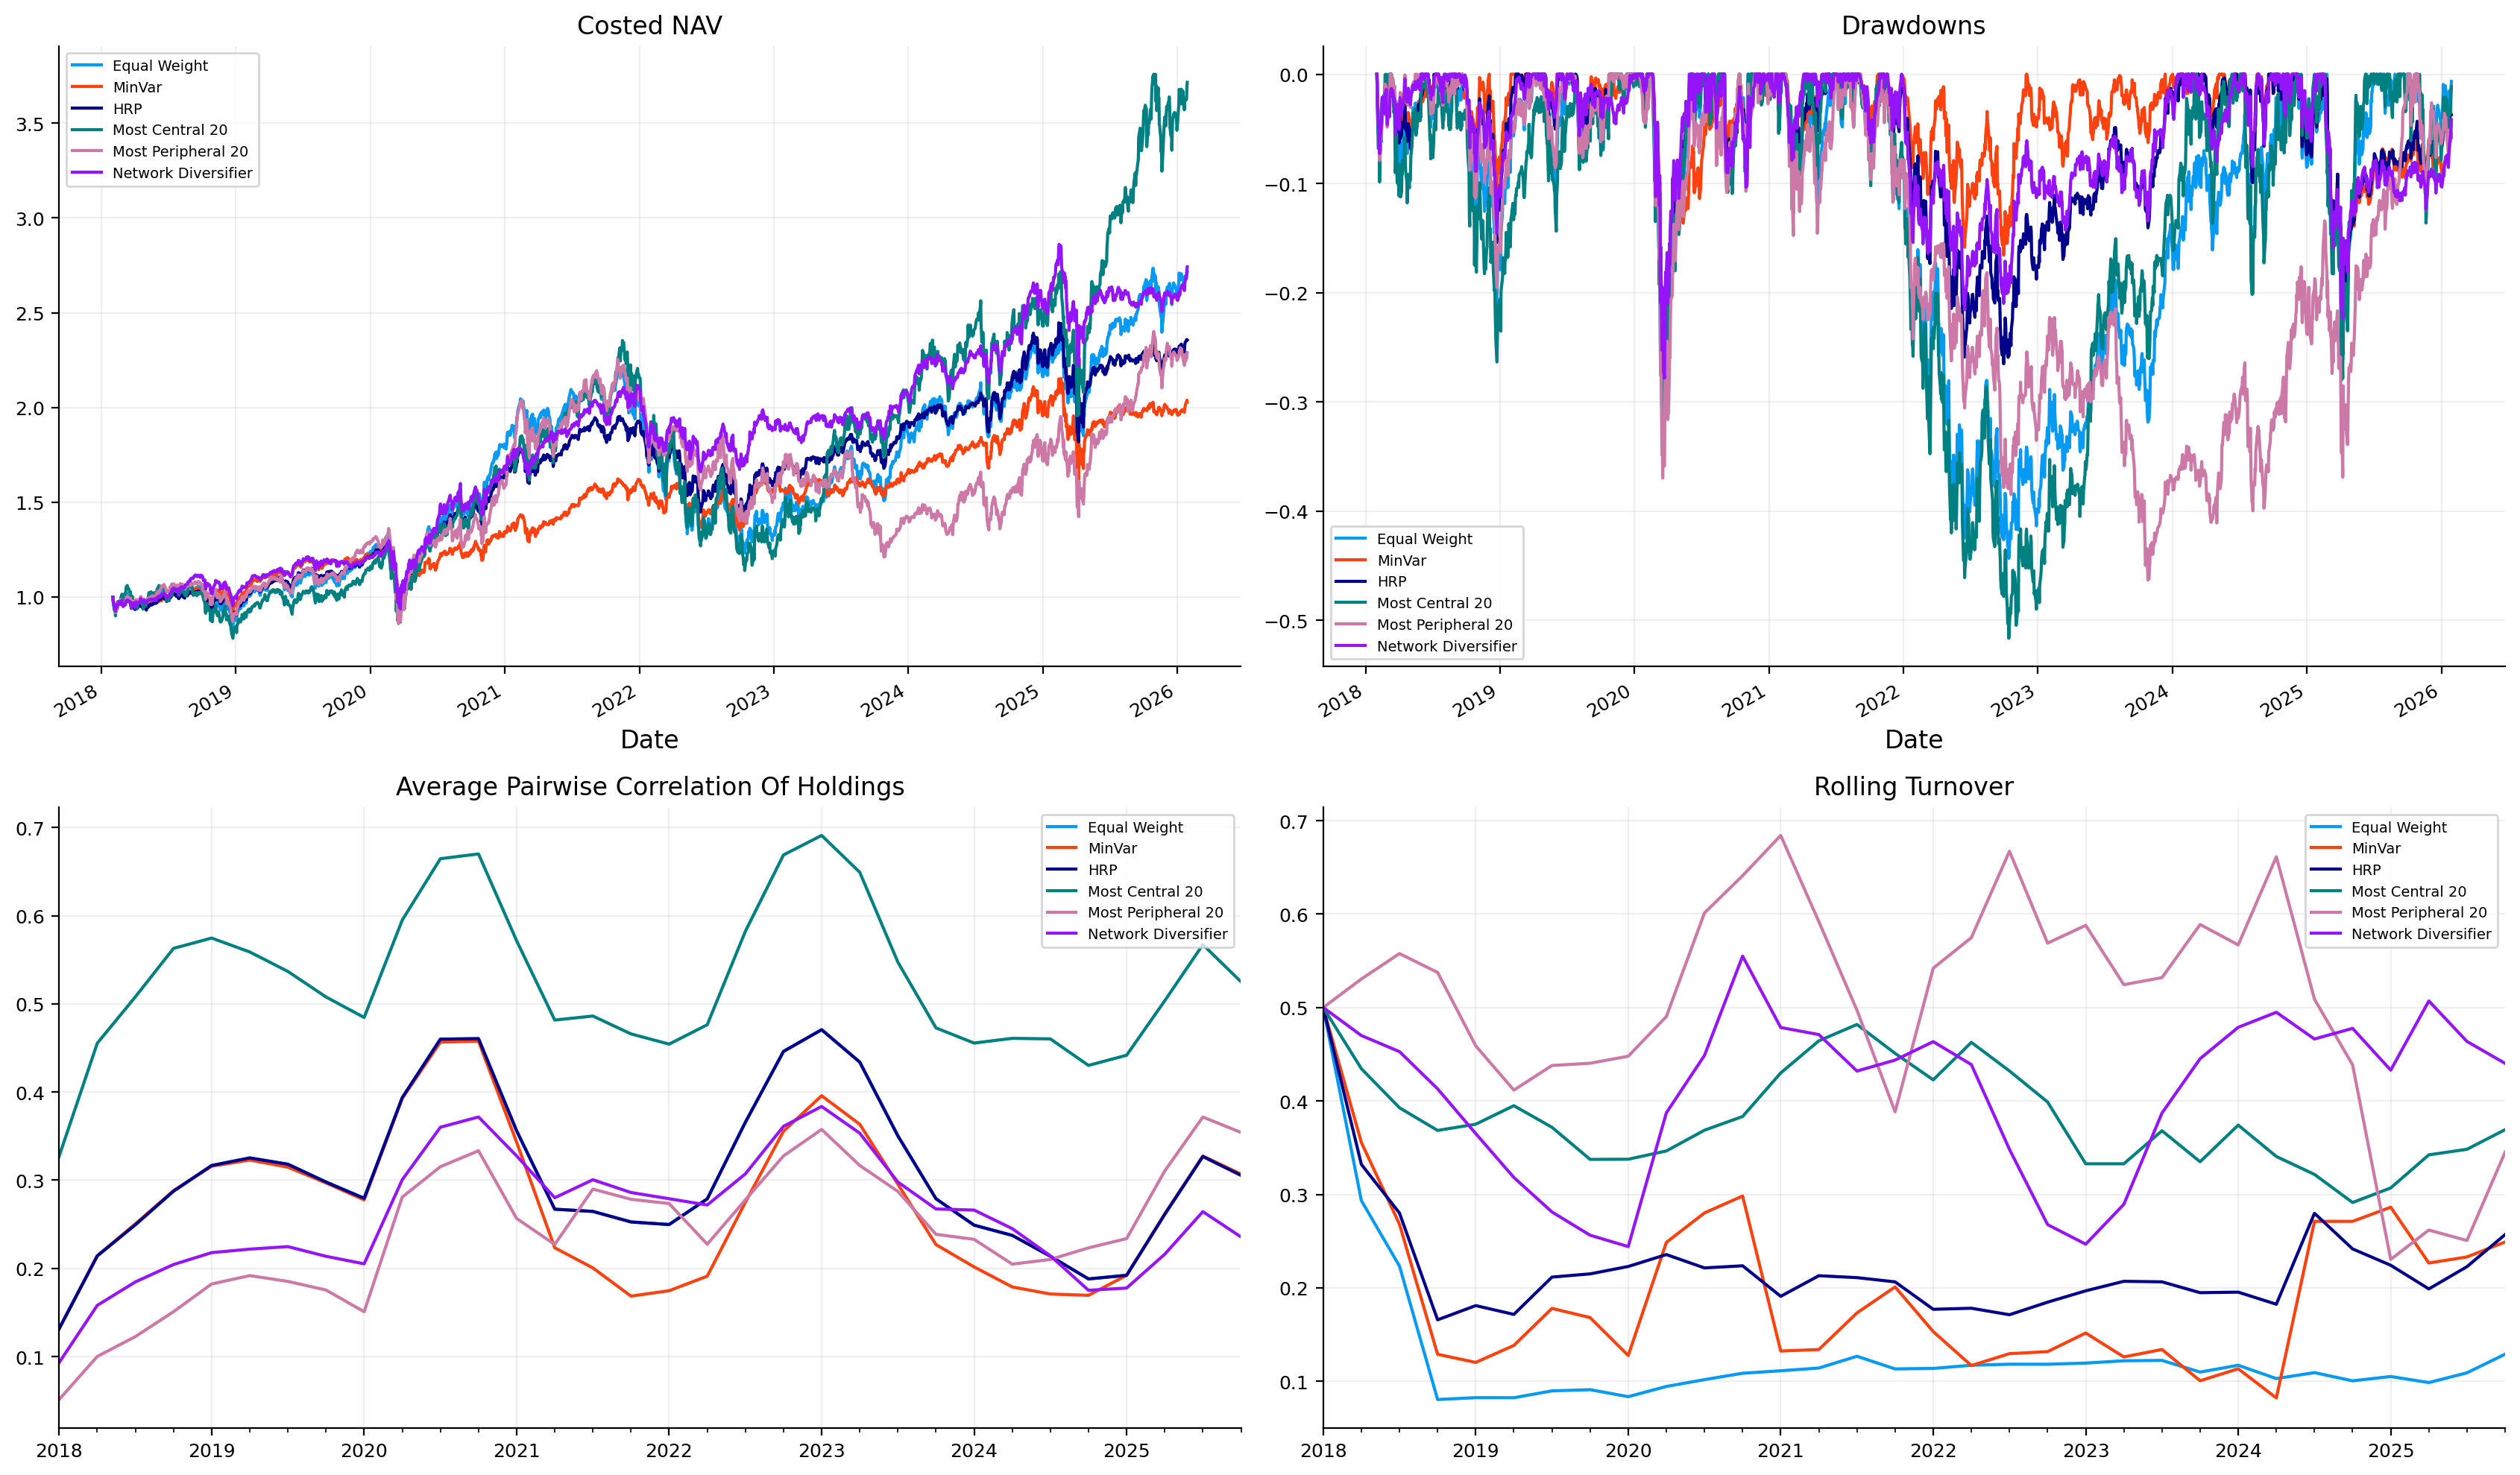

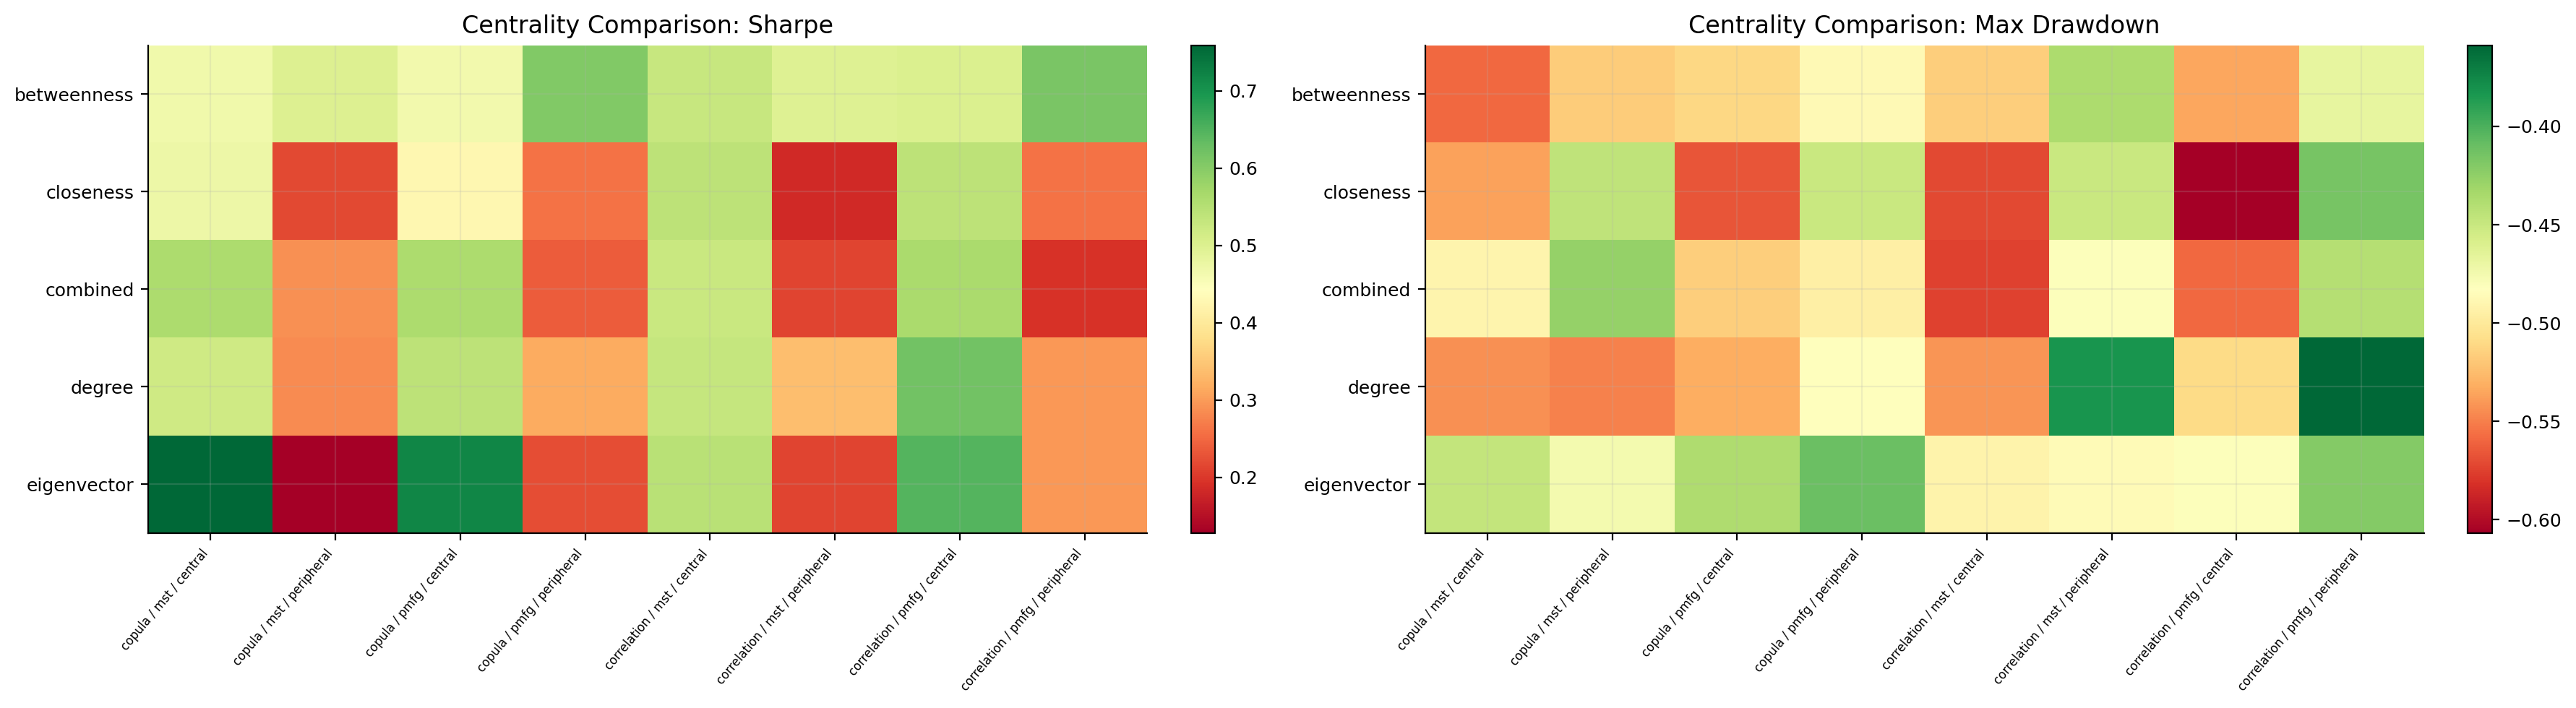

In [31]:
def comparison_heatmap(ax, frame, value, title):
    plot_frame = frame.copy()
    plot_frame["setup"] = (
        plot_frame["dependence"] + " / " + plot_frame["network"] + " / " + plot_frame["direction"]
    )
    matrix = plot_frame.pivot_table(index="centrality", columns="setup", values=value, aggfunc="mean")
    image = ax.imshow(matrix.to_numpy(), aspect="auto", cmap="RdYlGn")
    ax.set_title(title)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=50, ha="right", fontsize=6)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


nav = pd.concat({name: result.net_values for name, result in results.items()}, axis=1)
drawdowns = nav / nav.cummax() - 1.0
turnover = pd.concat({name: result.turnover for name, result in results.items()}, axis=1)
pair_corr = pd.DataFrame(
    {name: pairwise_corr_for_weights(ret_d, result.weights) for name, result in results.items()}
)

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
nav.plot(ax=axes[0, 0], title="Costed NAV")
drawdowns.plot(ax=axes[0, 1], title="Drawdowns")
pair_corr.rolling(3, min_periods=1).mean().plot(ax=axes[1, 0], title="Average Pairwise Correlation Of Holdings")
turnover.rolling(3, min_periods=1).mean().plot(ax=axes[1, 1], title="Rolling Turnover")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
comparison_heatmap(axes[0], centrality_comparison, "Sharpe", "Centrality Comparison: Sharpe")
comparison_heatmap(axes[1], centrality_comparison, "Max Drawdown", "Centrality Comparison: Max Drawdown")
fig.tight_layout()
plt.show()


## Risk Report


,object,start,end,depth,duration
0,Equal Weight,2021-11-09,2024-11-05,-0.4432,752
1,MinVar,2020-02-21,2020-09-01,-0.3055,135
2,HRP,2020-02-20,2020-06-02,-0.2834,72
3,Most Central 20,2021-11-17,2024-03-06,-0.5164,577
4,Most Peripheral 20,2021-11-04,2025-10-01,-0.4631,980
5,Network,2020-02-21,2020-05-28,-0.2783,68


,hist_var5,hist_es5,cf_var5,cf_es5
object,,,,
Equal Weight,0.0269,0.0387,0.0252,0.0498
HRP,0.0180,0.0299,0.0167,0.0519
MinVar,0.0154,0.0268,0.0134,0.0595
Most Central 20,0.0324,0.0450,0.0294,0.0545
Most Peripheral 20,0.0250,0.0368,0.0240,0.0554
Network,0.0169,0.0274,0.0167,0.0469


,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2018_q4,Equal Weight,-0.1480,-0.2010,-0.0424,-0.0778
2018_q4,HRP,-0.1007,-0.1451,-0.0289,-0.0659
2018_q4,MinVar,-0.0625,-0.1164,-0.0288,-0.0567
2018_q4,Most Central 20,-0.1805,-0.2386,-0.0555,-0.0815
2018_q4,Most Peripheral 20,-0.1449,-0.1835,-0.0342,-0.0732
2018_q4,Network,-0.1010,-0.1425,-0.0289,-0.0552
2020_covid,Equal Weight,-0.1139,-0.3194,-0.1252,-0.1361
2020_covid,HRP,-0.0947,-0.2833,-0.1141,-0.1302
2020_covid,MinVar,-0.1195,-0.3055,-0.1156,-0.1469


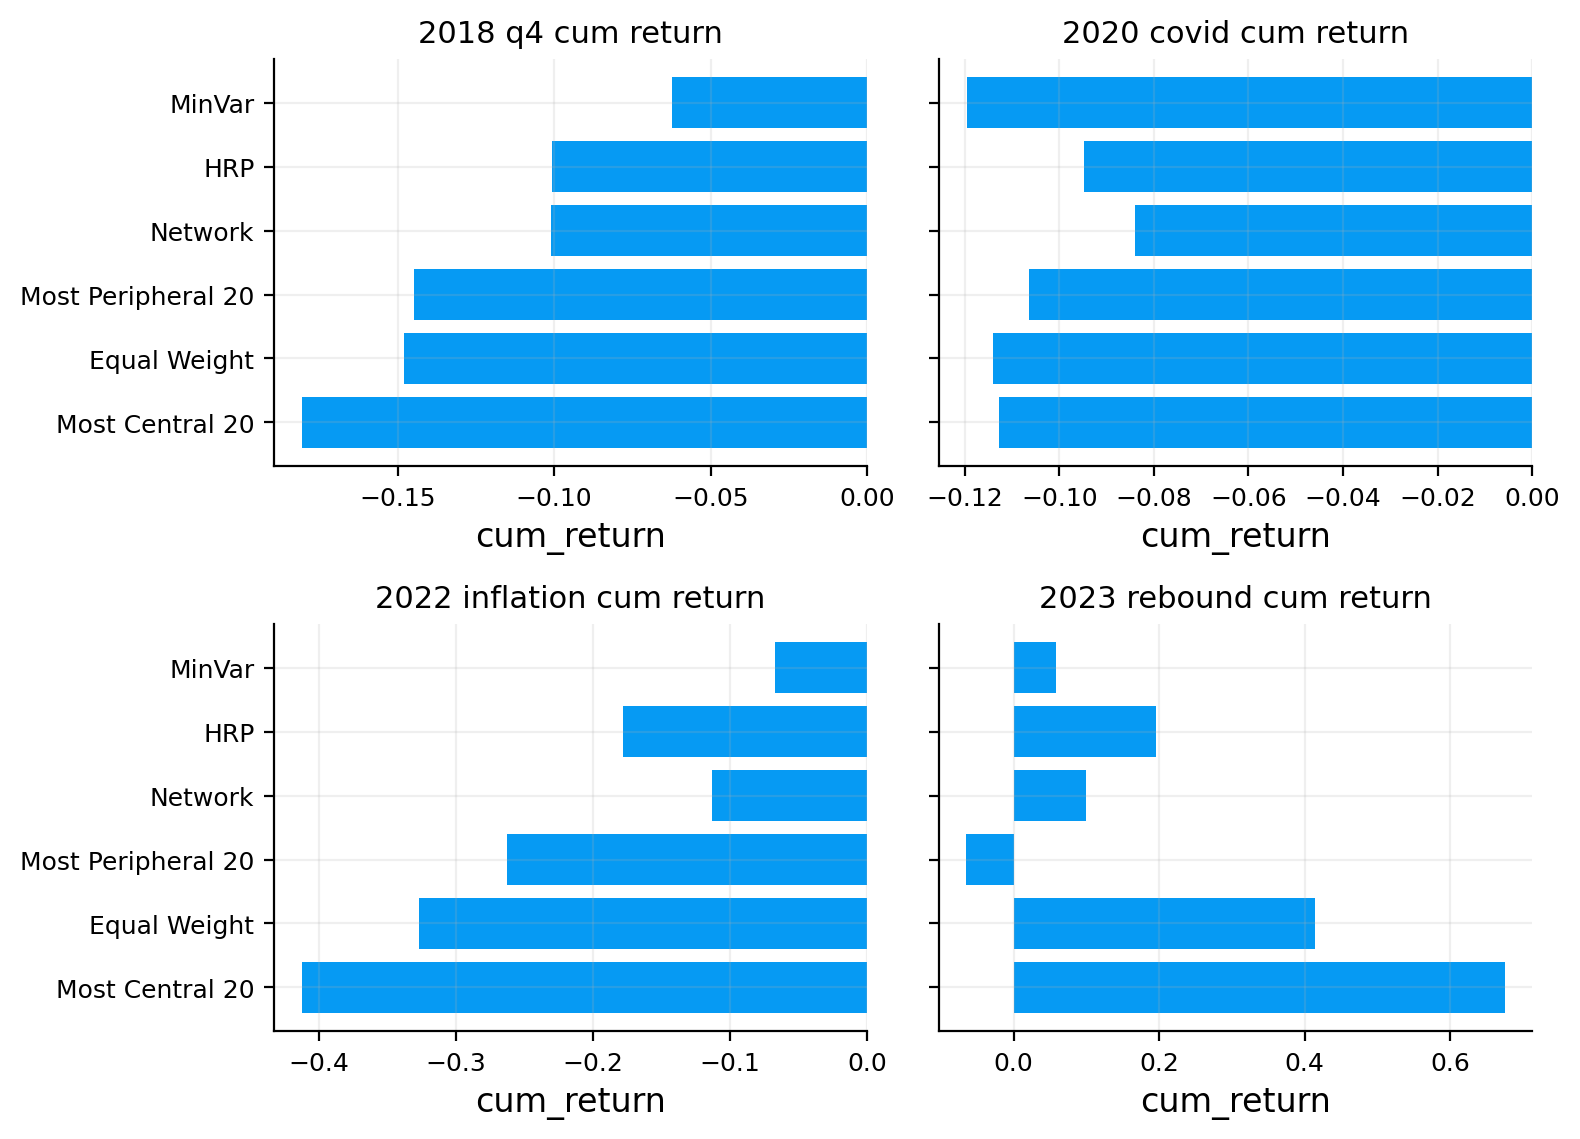

In [32]:
stress_windows = {
    "2018_q4": ("2018-10-01", "2018-12-31"),
    "2020_covid": ("2020-02-20", "2020-04-30"),
    "2022_inflation": ("2022-01-03", "2022-10-31"),
    "2023_rebound": ("2023-01-01", "2023-12-31"),
}
risk = risk_report(
    objects={name: result.net_returns for name, result in results.items()},
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": True,
        "var_es": True,
        "var_backtest": False,
        "stress": True,
        "capm": False,
        "rolling_beta": False,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf"], "lookback": 252},
    stress_settings={"windows": stress_windows, "worst_only": False},
    output={"display_tables": True, "show_figures": False, "round_tables": 4},
)


## Secondary HKEX Implementation


,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Turnover,Cost Drag,Effective N
Strategy,,,,,,,,
Equal Weight,0.0524,0.2188,0.1679,-0.3768,0.1391,0.0979,0.0019,100.0000
MinVar,0.0188,0.1415,-0.0691,-0.3281,0.0572,0.1334,0.0031,17.0087
HRP,0.0499,0.1693,0.1459,-0.3030,0.1647,0.1814,0.0037,56.1880
Most Central 20,0.0464,0.2516,0.1523,-0.3975,0.1167,0.3210,0.0058,20.0000
Most Peripheral 20,0.0713,0.2031,0.2543,-0.4361,0.1635,0.4844,0.0089,20.0000
Network Diversifier,0.0869,0.1669,0.3564,-0.3010,0.2887,0.3903,0.0070,21.8950


,central_choice,central_sharpe,central_source,peripheral_choice,peripheral_sharpe,peripheral_source,network_choice,network_sharpe,network_source
date,,,,,,,,,
2023-07-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|pmfg|closeness,0.044366,train-fixed,peripheral|correlation|pmfg|closeness,0.044366,train-fixed
2023-10-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|pmfg|closeness,-0.174725,train-fixed,peripheral|correlation|pmfg|closeness,-0.174725,train-fixed
2024-01-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|pmfg|closeness,-0.141265,train-fixed,peripheral|correlation|pmfg|closeness,-0.141265,train-fixed
2024-04-30,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|pmfg|closeness,0.128197,train-fixed,peripheral|correlation|pmfg|closeness,0.128197,train-fixed
2024-07-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|pmfg|closeness,0.170768,train-fixed,peripheral|correlation|pmfg|closeness,0.170768,train-fixed
2024-10-31,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|mst|closeness,0.730215,rolling,peripheral|correlation|mst|closeness,0.730215,rolling
2025-01-28,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|pmfg|closeness,0.069512,train-fixed,peripheral|correlation|pmfg|closeness,0.069512,train-fixed
2025-04-30,central|copula|pmfg|combined,NaN,fixed,peripheral|correlation|pmfg|closeness,0.208290,train-fixed,peripheral|correlation|pmfg|closeness,0.208290,train-fixed


,Most Central 20,Most Peripheral 20,Network Diversifier
central|copula|pmfg|combined,30,0,0
peripheral|correlation|pmfg|closeness,0,11,11
peripheral|copula|pmfg|combined,0,9,9
peripheral|correlation|mst|degree,0,4,4
peripheral|copula|pmfg|degree,0,3,3
peripheral|correlation|pmfg|combined,0,1,1
peripheral|copula|mst|closeness,0,1,1
peripheral|correlation|mst|closeness,0,1,1


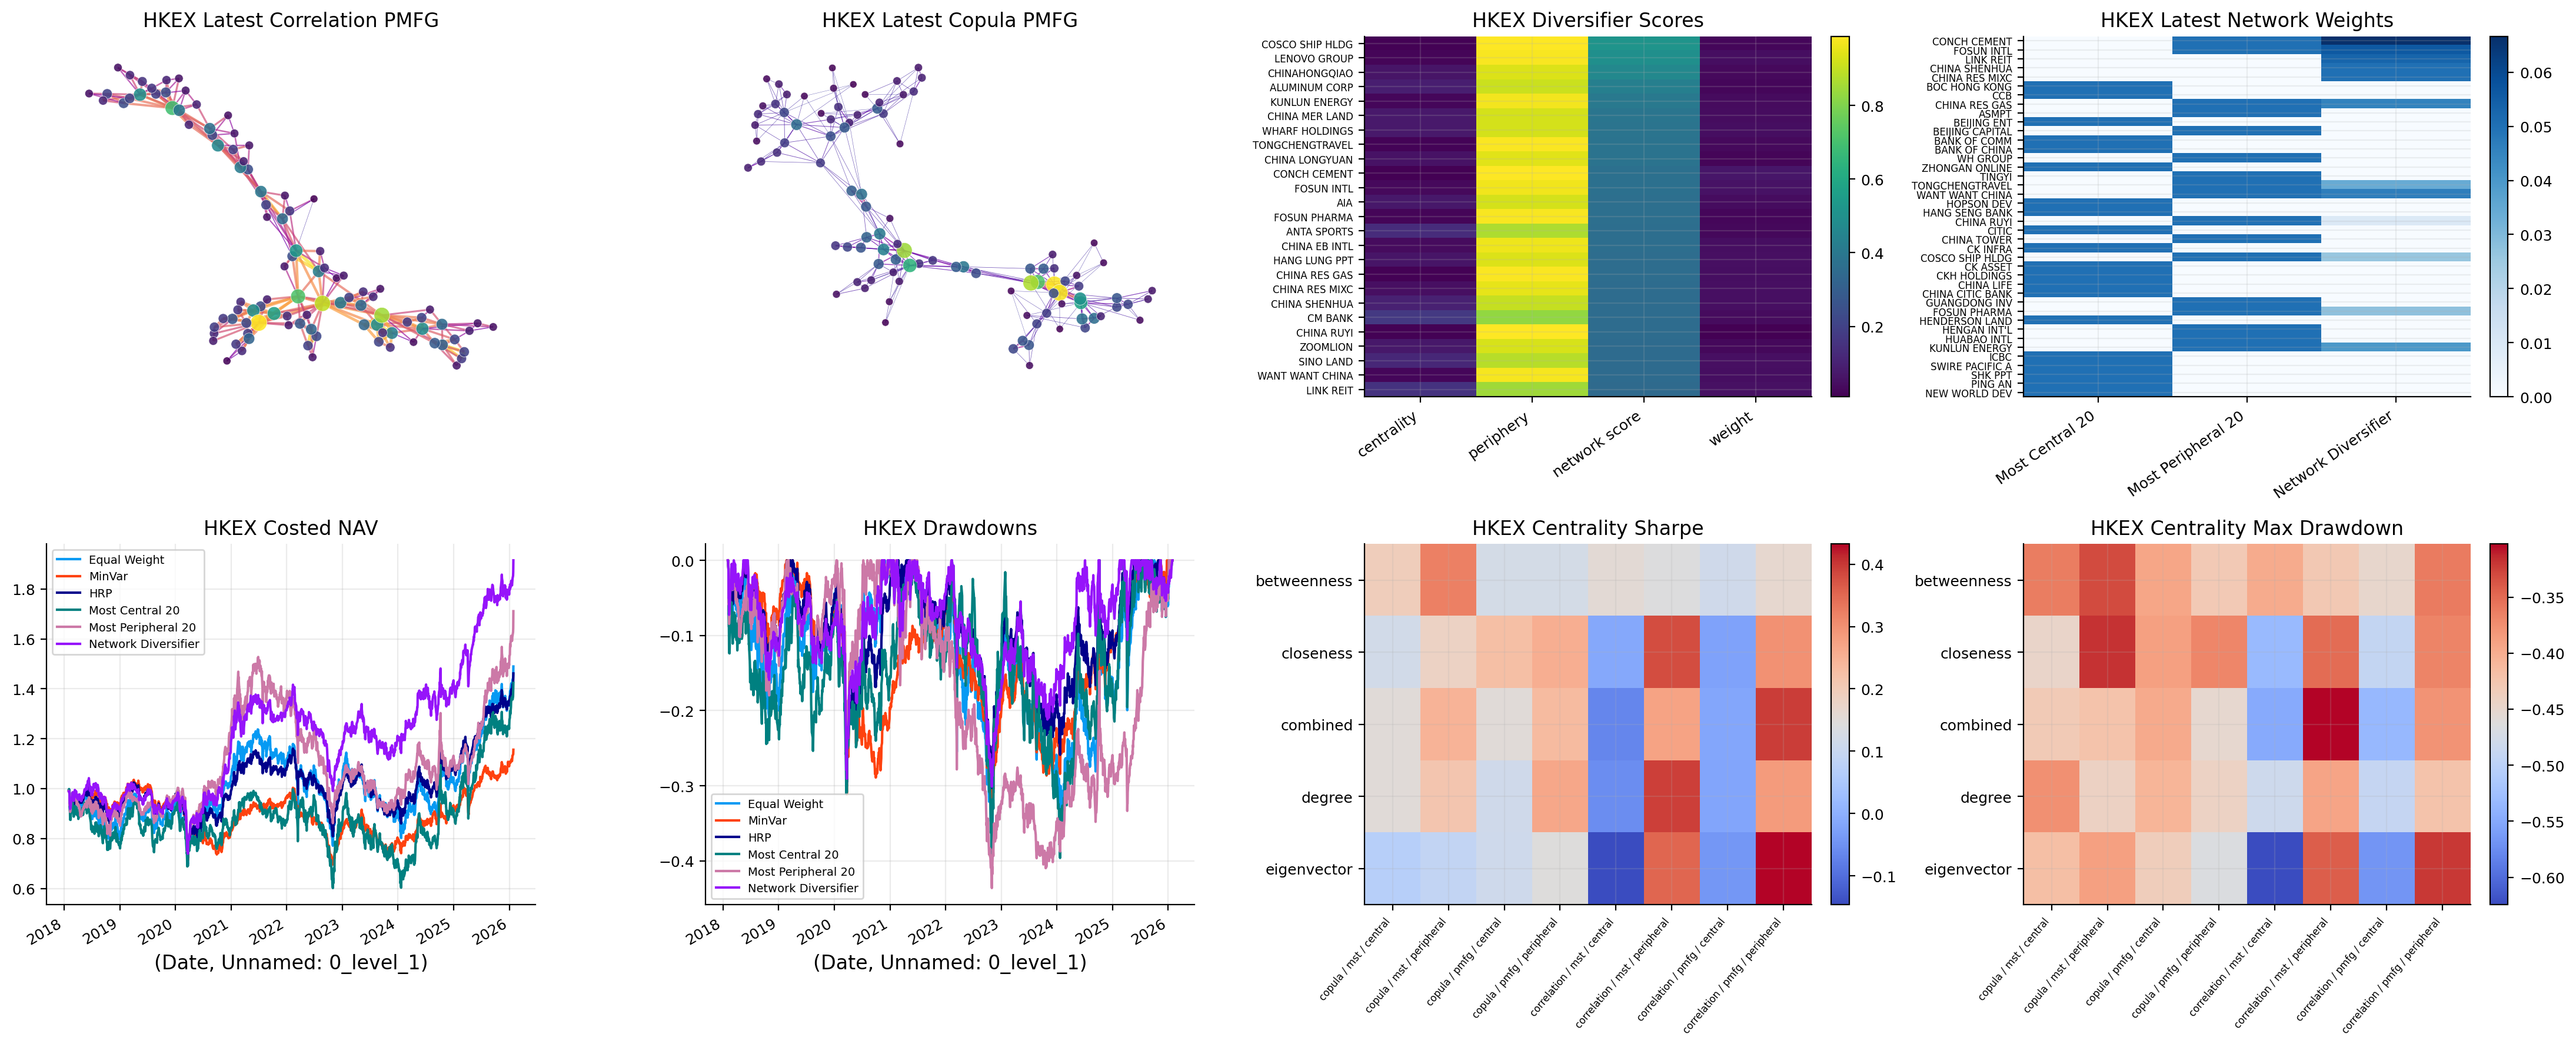

,object,start,end,depth,duration
0,Equal Weight,2021-06-28,2025-07-10,-0.3768,991
1,MinVar,2019-04-04,2025-06-23,-0.3281,1528
2,HRP,2022-02-14,2024-09-30,-0.3030,646
3,Most Central 20,2018-02-05,2024-09-30,-0.3975,1636
4,Most Peripheral 20,2021-06-29,2025-11-11,-0.4361,1075
5,Network,2022-02-14,2024-07-03,-0.3010,585


,hist_var5,hist_es5,cf_var5,cf_es5
object,,,,
Equal Weight,0.0209,0.0308,0.0224,0.0447
HRP,0.0167,0.0245,0.0178,0.0357
MinVar,0.0135,0.0208,0.0152,0.0277
Most Central 20,0.0231,0.0333,0.0244,0.0457
Most Peripheral 20,0.0206,0.0300,0.0216,0.0374
Network,0.0164,0.0248,0.0178,0.0319


,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2018_q4,Equal Weight,-0.0592,-0.0918,-0.0371,-0.0372
2018_q4,HRP,-0.0373,-0.0746,-0.0282,-0.0340
2018_q4,MinVar,-0.0243,-0.0685,-0.0243,-0.0322
2018_q4,Most Central 20,-0.0565,-0.0861,-0.0373,-0.0443
2018_q4,Most Peripheral 20,-0.0202,-0.0766,-0.0335,-0.0410
2018_q4,Network,-0.0388,-0.0723,-0.0284,-0.0447
2020_covid,Equal Weight,-0.1100,-0.2510,-0.0512,-0.1016
2020_covid,HRP,-0.1066,-0.2401,-0.0489,-0.0953
2020_covid,MinVar,-0.1071,-0.2427,-0.0593,-0.0957


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantfinlab.dataio.panel import load_yfinance_panel, prices_to_returns_panel
from quantfinlab.portfolio import covariance, expected_returns
from quantfinlab.portfolio.universe import (
    build_liquid_universe_by_date,
    clean_close_volume_panels,
    make_rebalance_dates,
)
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.portfolio.hrp import hrp_weight_frame
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.portfolio.selection import build_strategy_summary, performance_metrics
from quantfinlab.reports.risk_report import risk_report
from quantfinlab.portfolio.network import (
    central_peripheral_weights,
    centrality_table,
    corr_distance,
    dense_network,
    dependence_to_distance,
    kendall_to_t_copula_corr,
    mst_network,
    network_diversifier_weights,
    network_score,
    pairwise_corr_for_weights,
    pmfg_network,
    pseudo_observations,
    scale_01,
    select_t_copula_nu,
    shrink_corr,
    student_t_tail_dependence,
)
from quantfinlab.plotting.portfolio import (
    corr_heatmap,
    distance_heatmap,
    network_graph,
    performance_heatmap,
    score_heatmap,
    tail_heatmap,
    weight_heatmap,
)

annualization_hk = 252
rf_annual_hk = 0.04
rf_daily_hk = (1.0 + rf_annual_hk) ** (1.0 / annualization_hk) - 1.0
w_max_hk = 0.10

data_path = Path("../data")
if not (data_path / "hkex_selected_close_volume.csv").exists():
    data_path = Path("data")

panel = load_yfinance_panel(
    data_path / "hkex_selected_close_volume.csv",
    fields=("close", "volume"),
    source="hkex_csv",
    start="2016-01-01",
)
close_hk, volume_hk = clean_close_volume_panels(
    panel["close"], panel["volume"], start="2016-01-01", min_price=1.0
)
ret_hk = prices_to_returns_panel(close_hk).replace([np.inf, -np.inf], np.nan).dropna(how="all")
monthly_candidates_hk = make_rebalance_dates(close_hk.index, freq="M", min_history_days=504)
sampled_dates_hk = pd.DatetimeIndex(monthly_candidates_hk[::3])
universe_hk = build_liquid_universe_by_date(
    close=close_hk,
    volume=volume_hk,
    rebalance_dates=sampled_dates_hk,
    top_n=100,
    liquidity_lookback=252,
    min_listing_days=504,
    min_obs=220,
    min_price=1.0,
)
dates_hk = pd.DatetimeIndex([dt for dt in sampled_dates_hk if dt in universe_hk])

grid_hk = run_walkforward_grid(
    returns=ret_hk,
    close=close_hk,
    volume=volume_hk,
    rebalance_dates=dates_hk,
    universe_by_date=universe_hk,
    mu_models={"Momentum": expected_returns.momentum_mu},
    cov_models={"LedoitWolf": covariance.ledoit_wolf_covariance},
    strategy_specs=[
        {"name": "Equal Weight", "optimizer": "EW"},
        {"name": "MinVar", "optimizer": "MinVar", "cov_model": "LedoitWolf"},
    ],
    cov_lookback=252,
    mu_lookback=252,
    min_cov_observations=220,
    min_mu_observations=220,
    max_weight=w_max_hk,
    min_weight=0.0,
    trading_cost_bps=10,
    turnover_penalty_bps=10,
    fallback="equal",
    rf_daily=rf_daily_hk,
)
w_equal_hk = grid_hk.weights["Equal Weight"].copy()
w_minvar_hk = grid_hk.weights["MinVar"].copy()
w_hrp_hk = hrp_weight_frame(
    grid_hk.cache,
    grid_hk.metadata["rebalance_dates"],
    cov_model="LedoitWolf",
    linkage_method="average",
    w_min=0.0,
    w_max=w_max_hk,
)

first_hk = dates_hk[0]
window_first_hk = ret_hk.loc[:first_hk, universe_hk[first_hk]["tickers"]].tail(252).dropna(axis=0, how="any")
corr_first_hk = shrink_corr(window_first_hk)
dist_first_hk = corr_distance(corr_first_hk)
u_first_hk = pseudo_observations(window_first_hk)
nu_first_hk = select_t_copula_nu(u_first_hk, nu_grid=(4, 7, 15), max_pairs=40)
tail_first_hk = student_t_tail_dependence(kendall_to_t_copula_corr(u_first_hk), nu_first_hk)
tail_dist_first_hk = dependence_to_distance(tail_first_hk)
first_networks_hk = {
    "Correlation Dense": dense_network(corr_first_hk, distance=dist_first_hk),
    "Correlation PMFG": pmfg_network(corr_first_hk, distance=dist_first_hk),
    "Correlation MST": mst_network(corr_first_hk, distance=dist_first_hk),
    "Copula Dense": dense_network(tail_first_hk, distance=tail_dist_first_hk),
    "Copula PMFG": pmfg_network(tail_first_hk, distance=tail_dist_first_hk),
    "Copula MST": mst_network(tail_first_hk, distance=tail_dist_first_hk),
}

store_hk, comparison_rows_hk = {}, {}
for dt in dates_hk:
    window = ret_hk.loc[:dt, universe_hk[dt]["tickers"]].tail(252).dropna(axis=0, how="any")
    if window.shape[0] < 220 or window.shape[1] < 50:
        continue
    corr = shrink_corr(window)
    corr_dist = corr_distance(corr)
    pseudo = pseudo_observations(window)
    nu = select_t_copula_nu(pseudo, nu_grid=(4, 7, 15), max_pairs=40)
    tail = student_t_tail_dependence(kendall_to_t_copula_corr(pseudo), nu)
    tail_dist = dependence_to_distance(tail)
    graphs = {
        ("correlation", "pmfg"): pmfg_network(corr, distance=corr_dist),
        ("correlation", "mst"): mst_network(corr, distance=corr_dist),
        ("copula", "pmfg"): pmfg_network(tail, distance=tail_dist),
        ("copula", "mst"): mst_network(tail, distance=tail_dist),
    }
    centralities = {key: centrality_table(graph) for key, graph in graphs.items()}
    for (dependence, network_type), centrality in centralities.items():
        for measure in ["degree", "eigenvector", "betweenness", "closeness", "combined"]:
            central = scale_01(centrality[measure])
            for direction, selection_score in {"central": central, "peripheral": 1.0 - central}.items():
                key = f"{direction}|{dependence}|{network_type}|{measure}"
                comparison_rows_hk.setdefault(key, {})[dt] = central_peripheral_weights(
                    selection_score, returns=window, n_stocks=20, max_weight=w_max_hk
                )
    store_hk[dt] = {
        "window": window,
        "corr": corr,
        "corr_dist": corr_dist,
        "tail": tail,
        "tail_dist": tail_dist,
        "nu": nu,
        "graphs": graphs,
        "centralities": centralities,
    }

model_dates_hk = (
    pd.DatetimeIndex(sorted(store_hk))
    .intersection(w_equal_hk.index)
    .intersection(w_minvar_hk.index)
    .intersection(w_hrp_hk.index)
)
comparison_weights_hk = {
    key: pd.DataFrame.from_dict(rows, orient="index").fillna(0.0)
    for key, rows in comparison_rows_hk.items()
}
comparison_cols_hk = sorted(set().union(*(set(frame.columns) for frame in comparison_weights_hk.values())))
comparison_weights_hk = {
    name: frame.reindex(index=model_dates_hk, columns=comparison_cols_hk).fillna(0.0)
    for name, frame in comparison_weights_hk.items()
}
comparison_results_hk = run_many_weights_backtests(
    comparison_weights_hk,
    returns=ret_hk.reindex(columns=comparison_cols_hk).fillna(0.0),
    cost_bps=10,
    w_min=0.0,
    w_max=w_max_hk,
    long_only=True,
    weight_timing="next_close",
)
comparison_table_hk = []
for name, result in comparison_results_hk.items():
    direction, dependence, network_type, measure = name.split("|")
    metrics = performance_metrics(result.net_returns, result.net_values, rf_daily=rf_daily_hk, annualization=annualization_hk)
    comparison_table_hk.append(
        {
            "direction": direction,
            "dependence": dependence,
            "network": network_type,
            "centrality": measure,
            "Sharpe": metrics["Sharpe"],
            "Max Drawdown": metrics["Max Drawdown"],
            "Calmar": metrics["Calmar"],
            "turnover": float(result.turnover.mean()),
            "avg_pairwise_corr": float(pairwise_corr_for_weights(ret_hk, result.weights).mean()),
        }
    )
comparison_hk = pd.DataFrame(comparison_table_hk)
comparison_hk["sharpe"] = comparison_hk["Sharpe"]
comparison_hk["max_drawdown"] = comparison_hk["Max Drawdown"]


def parse_hk_choice(name):
    direction, dependence, network_type, measure = name.split("|")
    return direction, dependence, network_type, measure


def rolling_hk_choice(results, dt, direction, lookback_years=2, min_obs=252):
    fallback = f"{direction}|copula|pmfg|combined"
    start = pd.Timestamp(dt) - pd.DateOffset(years=lookback_years)
    rows = []
    for name, result in results.items():
        if not name.startswith(f"{direction}|"):
            continue
        returns_window = result.net_returns.loc[
            (result.net_returns.index >= start) & (result.net_returns.index < dt)
        ].dropna()
        if len(returns_window) < min_obs:
            continue
        nav_window = (1.0 + returns_window).cumprod()
        metrics = performance_metrics(
            returns_window,
            nav_window,
            rf_daily=rf_daily_hk,
            annualization=annualization_hk,
        )
        turnover_window = result.turnover.loc[
            (result.turnover.index >= start) & (result.turnover.index < dt)
        ].dropna()
        rows.append(
            {
                "name": name,
                "Sharpe": metrics["Sharpe"],
                "Max Drawdown": metrics["Max Drawdown"],
                "Calmar": metrics["Calmar"],
                "turnover": float(turnover_window.mean()) if len(turnover_window) else np.nan,
            }
        )

    if not rows:
        return fallback, {"Sharpe": np.nan, "Max Drawdown": np.nan, "source": "fallback"}

    table = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
    if table.empty:
        return fallback, {"Sharpe": np.nan, "Max Drawdown": np.nan, "source": "fallback"}

    best = table.sort_values(
        ["Sharpe", "Max Drawdown", "turnover"],
        ascending=[False, False, True],
    ).iloc[0]
    return best["name"], {
        "Sharpe": float(best["Sharpe"]),
        "Max Drawdown": float(best["Max Drawdown"]),
        "source": "rolling",
    }


def train_hk_choice(results, direction, train_end, min_obs=252):
    fallback = f"{direction}|copula|pmfg|combined"
    rows = []
    for name, result in results.items():
        if not name.startswith(f"{direction}|"):
            continue
        returns_window = result.net_returns.loc[result.net_returns.index < train_end].dropna()
        if len(returns_window) < min_obs:
            continue
        nav_window = (1.0 + returns_window).cumprod()
        metrics = performance_metrics(
            returns_window,
            nav_window,
            rf_daily=rf_daily_hk,
            annualization=annualization_hk,
        )
        turnover_window = result.turnover.loc[result.turnover.index < train_end].dropna()
        rows.append(
            {
                "name": name,
                "Sharpe": metrics["Sharpe"],
                "Max Drawdown": metrics["Max Drawdown"],
                "turnover": float(turnover_window.mean()) if len(turnover_window) else np.nan,
            }
        )
    if not rows:
        return fallback
    table = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
    if table.empty:
        return fallback
    return table.sort_values(["Sharpe", "Max Drawdown", "turnover"], ascending=[False, False, True]).iloc[0]["name"]


selector_train_end_hk = model_dates_hk[min(8, len(model_dates_hk) - 1)]
central_fixed_hk = "central|copula|pmfg|combined"
peripheral_train_hk = train_hk_choice(comparison_results_hk, "peripheral", selector_train_end_hk)


def stability_gated_hk_choice(results, dt, direction, train_selection, threshold=0.50):
    if pd.Timestamp(dt) <= selector_train_end_hk:
        return f"{direction}|copula|pmfg|combined", {"Sharpe": np.nan, "source": "fallback"}
    rolling_name, rolling_info = rolling_hk_choice(results, dt, direction)
    if not np.isfinite(rolling_info["Sharpe"]) or rolling_info["Sharpe"] < threshold:
        return train_selection, {"Sharpe": rolling_info["Sharpe"], "source": "train-fixed"}
    return rolling_name, rolling_info


selection_records_hk = []
central_rows_hk, peripheral_rows_hk, diversifier_rows_hk = {}, {}, {}
for dt in model_dates_hk:
    central_choice = central_fixed_hk
    central_info = {"Sharpe": np.nan, "source": "fixed"}
    peripheral_choice, peripheral_info = stability_gated_hk_choice(
        comparison_results_hk, dt, "peripheral", peripheral_train_hk
    )
    network_choice, network_info = stability_gated_hk_choice(
        comparison_results_hk, dt, "peripheral", peripheral_train_hk
    )
    selection_records_hk.append(
        {
            "date": dt,
            "central_choice": central_choice,
            "central_sharpe": central_info["Sharpe"],
            "central_source": central_info["source"],
            "peripheral_choice": peripheral_choice,
            "peripheral_sharpe": peripheral_info["Sharpe"],
            "peripheral_source": peripheral_info["source"],
            "network_choice": network_choice,
            "network_sharpe": network_info["Sharpe"],
            "network_source": network_info["source"],
        }
    )

    record = store_hk[dt]

    _, dependence, network_type, measure = parse_hk_choice(central_choice)
    centrality = record["centralities"][(dependence, network_type)]
    central_score = scale_01(centrality[measure])
    central_rows_hk[dt] = central_peripheral_weights(
        central_score, returns=record["window"], side="central", n_stocks=20, max_weight=w_max_hk
    )

    _, dependence, network_type, measure = parse_hk_choice(peripheral_choice)
    centrality = record["centralities"][(dependence, network_type)]
    periphery = 1.0 - scale_01(centrality[measure])
    peripheral_rows_hk[dt] = central_peripheral_weights(
        periphery, returns=record["window"], side="peripheral", n_stocks=20, max_weight=w_max_hk
    )

    _, dependence, network_type, measure = parse_hk_choice(network_choice)
    centrality = record["centralities"][(dependence, network_type)]
    periphery = 1.0 - scale_01(centrality[measure])
    scores = network_score(
        periphery,
        returns=record["window"],
        momentum_window=126,
        momentum_skip=0,
        volatility_window=126,
        drawdown_window=252,
    )
    diversifier_rows_hk[dt] = network_diversifier_weights(
        scores, returns=record["window"], n_stocks=25, max_weight=w_max_hk
    )

selection_hk = pd.DataFrame(selection_records_hk).set_index("date")
w_central_hk = pd.DataFrame.from_dict(central_rows_hk, orient="index").fillna(0.0)
w_peripheral_hk = pd.DataFrame.from_dict(peripheral_rows_hk, orient="index").fillna(0.0)
w_diversifier_hk = pd.DataFrame.from_dict(diversifier_rows_hk, orient="index").fillna(0.0)
common_index_hk = (
    w_diversifier_hk.index.intersection(w_equal_hk.index).intersection(w_minvar_hk.index).intersection(w_hrp_hk.index)
)
columns_hk = sorted(
    set(w_equal_hk.columns)
    | set(w_minvar_hk.columns)
    | set(w_hrp_hk.columns)
    | set(w_central_hk.columns)
    | set(w_peripheral_hk.columns)
    | set(w_diversifier_hk.columns)
)
weights_hk = {
    "Equal Weight": w_equal_hk.reindex(index=common_index_hk, columns=columns_hk).fillna(0.0),
    "MinVar": w_minvar_hk.reindex(index=common_index_hk, columns=columns_hk).fillna(0.0),
    "HRP": w_hrp_hk.reindex(index=common_index_hk, columns=columns_hk).fillna(0.0),
    "Most Central 20": w_central_hk.reindex(index=common_index_hk, columns=columns_hk).fillna(0.0),
    "Most Peripheral 20": w_peripheral_hk.reindex(index=common_index_hk, columns=columns_hk).fillna(0.0),
    "Network Diversifier": w_diversifier_hk.reindex(index=common_index_hk, columns=columns_hk).fillna(0.0),
}
results_hk = run_many_weights_backtests(
    weights_hk,
    returns=ret_hk.reindex(columns=columns_hk).fillna(0.0),
    cost_bps=10,
    w_min=0.0,
    w_max=w_max_hk,
    long_only=True,
    weight_timing="next_close",
    rf_daily=rf_daily_hk,
)
summary_hk = build_strategy_summary(results_hk, rf_daily=rf_daily_hk, annualization=annualization_hk)
display(summary_hk[["CAGR", "Vol", "Sharpe", "Max Drawdown", "Calmar", "Turnover", "Cost Drag", "Effective N"]].round(4))
display(selection_hk.tail(8))
display(
    pd.concat(
        {
            "Most Central 20": selection_hk["central_choice"].value_counts(),
            "Most Peripheral 20": selection_hk["peripheral_choice"].value_counts(),
            "Network Diversifier": selection_hk["network_choice"].value_counts(),
        },
        axis=1,
    ).fillna(0).astype(int)
)

latest_dt_hk = common_index_hk[-1]
latest_hk = store_hk[latest_dt_hk]
latest_network_choice_hk = selection_hk.loc[latest_dt_hk, "network_choice"]
_, latest_dependence_hk, latest_network_type_hk, latest_measure_hk = parse_hk_choice(latest_network_choice_hk)
centrality_hk = latest_hk["centralities"][(latest_dependence_hk, latest_network_type_hk)]
central_score_hk = scale_01(centrality_hk[latest_measure_hk])
periphery_hk = 1.0 - central_score_hk
network_scores_hk = network_score(periphery_hk, returns=latest_hk["window"])
score_frame_hk = pd.concat(
    {
        "centrality": central_score_hk,
        "periphery": periphery_hk,
        "network score": network_scores_hk,
        "weight": weights_hk["Network Diversifier"].loc[latest_dt_hk],
    },
    axis=1,
).sort_values("network score", ascending=False).head(25)
weight_frame_hk = pd.concat(
    {
        "Most Central 20": weights_hk["Most Central 20"].loc[latest_dt_hk],
        "Most Peripheral 20": weights_hk["Most Peripheral 20"].loc[latest_dt_hk],
        "Network Diversifier": weights_hk["Network Diversifier"].loc[latest_dt_hk],
    },
    axis=1,
).fillna(0.0)

nav_hk = pd.concat({name: result.net_values for name, result in results_hk.items()}, axis=1)
drawdowns_hk = nav_hk / nav_hk.cummax() - 1.0

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.ravel()

network_graph(
    axes[0],
    latest_hk["graphs"][("correlation", "pmfg")],
    title="HKEX Latest Correlation PMFG",
)
network_graph(
    axes[1],
    latest_hk["graphs"][("copula", "pmfg")],
    title="HKEX Latest Copula PMFG",
)
score_heatmap(axes[2], score_frame_hk, title="HKEX Diversifier Scores")
weight_heatmap(axes[3], weight_frame_hk, title="HKEX Latest Network Weights")
nav_hk.plot(ax=axes[4], title="HKEX Costed NAV")
drawdowns_hk.plot(ax=axes[5], title="HKEX Drawdowns")
performance_heatmap(axes[6], comparison_hk, value="sharpe", title="HKEX Centrality Sharpe")
performance_heatmap(axes[7], comparison_hk, value="max_drawdown", title="HKEX Centrality Max Drawdown")

for ax in axes[4:6]:
    ax.grid(True, alpha=0.25)

fig.tight_layout()
plt.show()

warnings.filterwarnings("ignore", message="obj.round has no effect with datetime, timedelta, or period dtypes.*", category=UserWarning)
risk_hk = risk_report(
    objects={name: result.net_returns for name, result in results_hk.items()},
    rf_daily=rf_daily_hk,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": True,
        "var_es": True,
        "var_backtest": False,
        "stress": True,
        "capm": False,
        "rolling_beta": False,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf"], "lookback": 252},
    stress_settings={
        "windows": {
            "2018_q4": ("2018-10-01", "2018-12-31"),
            "2020_covid": ("2020-02-20", "2020-04-30"),
            "2022_inflation": ("2022-01-03", "2022-10-31"),
            "2023_rebound": ("2023-01-01", "2023-12-31"),
        },
        "worst_only": False,
    },
    output={"display_tables": True, "show_figures": False, "round_tables": 4},
)
plt.close("all")
